In [1]:
# Automatic reloading of imports
%load_ext autoreload
%autoreload 2

import os
import sys
from astropy.io import fits
from astropy.time import Time
from astropy.constants import c
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy import ndimage
from scipy.interpolate import splrep, splev
from datetime import datetime
# Put in the pyodine path on your machine here!
pyodine_path = '/Users/jaklusmeyer/SONG/pyodine'
home_data_path = '/Users/jaklusmeyer/SONG'

#names for atlas template creation later in h5 format, will be saaved to pyodine_path/references/ 
starname = 'Arcturus'
datefortemplatename = datetime.now().strftime('%y%m%d')
atlas = 'Pepsi'

#atlas star name should be the same as starname--
ref_star = 'Arcturus' 

sys.path.append(pyodine_path)

import pyodine
import utilities_song_apo
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'bool'):
    np.bool = bool
if not hasattr(np, 'object'):
    np.object = object
if not hasattr(np, 'long'):
    np.long = int  # Python 3 doesn't have 'long'

/var/folders/rw/_tylhr6d7h5d4zl73ncpyn_80000gn/T/ipykernel_74025/2416723698.py:36: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'):
/var/folders/rw/_tylhr6d7h5d4zl73ncpyn_80000gn/T/ipykernel_74025/2416723698.py:38: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'object'):
/var/folders/rw/_tylhr6d7h5d4zl73ncpyn_80000gn/T/ipykernel_74025/2416723698.py:40: FutureWarning: In the future `np.long` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'long'):


this is used later from the APO file observations to match up with the pepsi template.  goes in cells after masking tellurics but moving it up because the rest should just run

In [2]:
obs_filepath = os.path.join(
    home_data_path, 'reduce', 'UT260216','sciencestar', 'Arcturus_ec.0341.fits'
)
print(obs_filepath)

/Users/jaklusmeyer/SONG/reduce/UT260216/sciencestar/Arcturus_ec.0341.fits


np.shape(data) (435550,)
Filename: /Users/jaklusmeyer/SONG/pepsi_templates/pepsib.20150409.026_alphaboo.sxt.awl.all6
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     211   ()      
  1  DataVector    1 BinTableHDU     35   435550R x 4C   ['1D', '1D', '1D', '1L']   
None
SIMPLE  =                    T       / Standard FITS format                     BITPIX  =                    8       / Bits per pixel                           NAXIS   =                    0       / Number of axes                           EXTEND  =                    T       / Extension is present                                                                                                     DETSIZE = '[1:10560,1:10560]'        / Detector size                            NCCDS   =                    1       / Number of CCDs                           NAMPS   =                   16       / Number of amplifiers                     PCIFILE = 'pci3.lod'                 / P

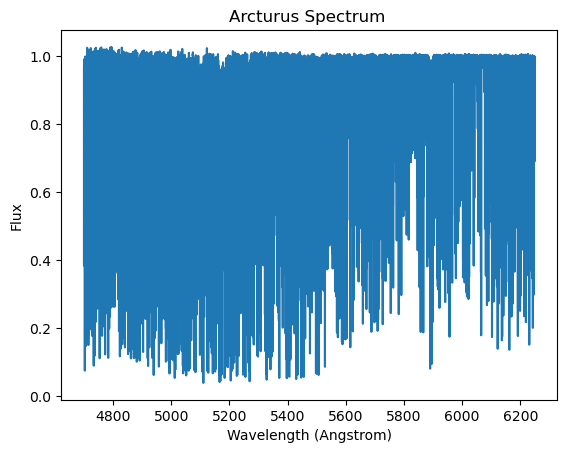

Valid points: 435550
Wavelength range: 3823.233960014047 - 9129.95079806279
Flux range: -1.03697102049004 - 3.634957930384194


In [3]:
import copy  # For deepcopy

# File path
ref_pathname = os.path.join(home_data_path,'pepsi_templates','pepsib.20150409.026_alphaboo.sxt.awl.all6')


# Open the FITS file and extract data
with fits.open(ref_pathname) as h:
    """hdr = h[0].header
    flux = h[0].data
    ref_flux = copy.deepcopy(flux)  # To preserve original
    crval1 = hdr['CRVAL1']  # Starting wavelength
    cdelt1 = hdr['CDELT1']  # Wavelength increment"""
    #naxis1 = hdr['NAXIS1']  # Number of data points"""
    
    data = h[1].data  
    print('np.shape(data)', np.shape(data))
    #print the header
    print(h.info())
    print(h[0].header)

    wavelength = data.field(0)  
    print(np.min(wavelength), np.max(wavelength))
    flux = data.field(1)
    ref_flux = copy.deepcopy(flux)
    error = data.field(2)
    mask = data.field(3)  
    
    
    wave = copy.deepcopy(wavelength) #crval1 + cdelt1 * np.arange(naxis1)
    ref_wave = copy.deepcopy(wave)
    #normalize flux
    #ref_flux = ref_flux / np.median(ref_flux)
    
    
    with fits.open(ref_pathname) as h:
        print("Filename:", ref_pathname)
        print("Number of HDUs:", len(h))
        print(h.info())

        # Inspect all HDUs; the spectrum is usually in the first BinTableHDU
        for i, hdu in enumerate(h):
            print(f"\nHDU {i}: {type(hdu).__name__}  name={hdu.name}")
            if hasattr(hdu, "columns") and hdu.columns is not None:
                print("  Columns:")
                for col in hdu.columns:
                    print(f"    {col.name:15s} format={col.format:8s} unit={col.unit} dim={col.dim}")

        # Choose the HDU you believe holds the spectrum (you used h[1])
        data = h[1].data
        cols = data.names
        print("\nUsing HDU 1 with columns:", cols)
        print("nrows:", len(data))

        # Safer: pull columns by name (fall back to index only if needed)
        def get_col(name_candidates, idx_fallback):
            for n in name_candidates:
                if n in cols:
                    return data[n]
            return data.field(idx_fallback)

        wavelength = get_col(["wave", "wavelength", "lambda", "lam", "WAVE", "WAVELENGTH"], 0)
        flux       = get_col(["flux", "FLUX"], 1)
        error      = get_col(["err", "error", "sigma", "unc", "UNC", "ERR"], 2)
        mask       = get_col(["mask", "MASK", "flag", "FLAGS"], 3)

        # Convert to plain numpy arrays (avoids FITS record quirks)
        wavelength = np.array(wavelength, dtype=float)
        flux       = np.array(flux, dtype=float)
        error      = np.array(error, dtype=float) if error is not None else None
        mask       = np.array(mask)

        print("\nColumn sanity:")
        print("  wavelength dtype/shape:", wavelength.dtype, wavelength.shape)
        print("  flux       dtype/shape:", flux.dtype, flux.shape)
        if error is not None:
            print("  error      dtype/shape:", error.dtype, error.shape)
        print("  mask       dtype/shape:", mask.dtype, mask.shape)

# Wavelength clipping range 4227.932304352416 6928.565858259893
wave_limits = (4700., 6250.)

# Clip wavelength and flux
ind = np.where((ref_wave > wave_limits[0]) & (ref_wave < wave_limits[1]))
ref_wave = ref_wave[ind]
ref_flux = ref_flux[ind]

# Plot clipped spectrum
plt.plot(ref_wave, ref_flux)
plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title(f'{starname} Spectrum ')
plt.show()

print("Valid points:", len(wavelength))
print("Wavelength range:", wavelength.min(), "-", wavelength.max())
print("Flux range:", flux.min(), "-", flux.max())

Nr. of identified tellurics:  0


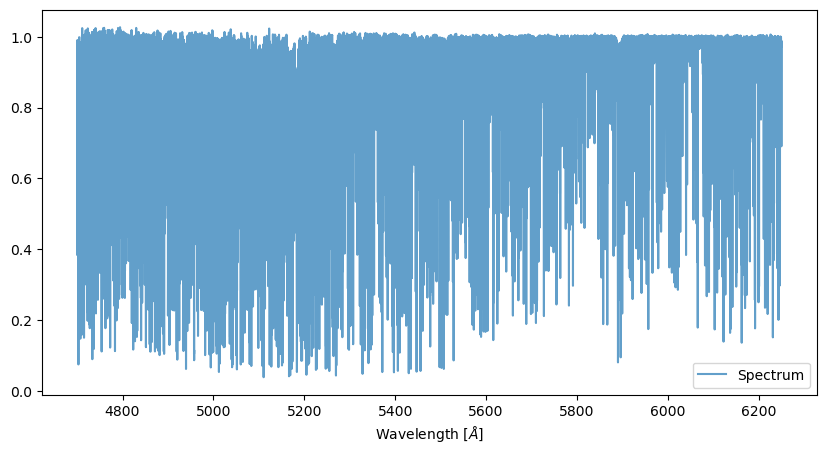

In [4]:
# Function to identify the telluric lines in the atlas
def identify_objects(image, threshold):
    """Modified from the internet: Returns a mask of numbers, 
    with the lowest value being the background (0), then 1 and 2 etc...
    
    http://stackoverflow.com/questions/5298884/finding-number-of-colored-shapes-from-picture-using-python
    """
    # Find connected components
    labeled, nr_objects = ndimage.label(image < threshold)
     
    return labeled, nr_objects

# Here we go: tellurics are around -1 in the spectrum (so below threshold of -0.5)
tell_mask, nr_tellurics = identify_objects(ref_flux, -0.5)
print("Nr. of identified tellurics: ", nr_tellurics)

# Plot spectrum and shade identified tellurics to check
fig = plt.figure(figsize=(10,5))
plt.plot(ref_wave, ref_flux, alpha=0.7)
for i in range(nr_tellurics):
    plt.axvspan(ref_wave[np.where(tell_mask==i+1)[0][0]], 
                ref_wave[np.where(tell_mask==i+1)[0][-1]], 
                color='k', alpha=0.3)
plt.legend(['Spectrum', 'Tellurics'])
plt.xlabel(r'Wavelength [$\AA$]')
#plt.xlim(5220, 5240)
plt.show()

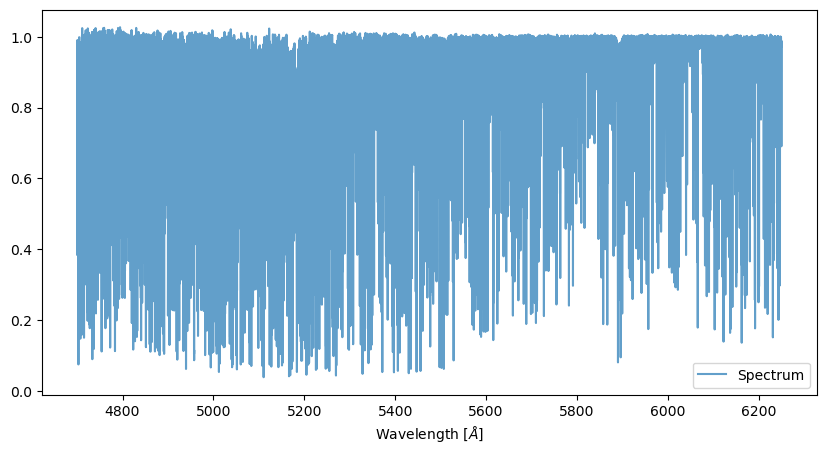

In [5]:
# Now loop through the telluric features and "fix" them (through interpolation)
ref_flux2 = ref_flux.copy()
for i in range(nr_tellurics):
    ind = np.where(tell_mask==i+1)
    tell_wave = ref_wave[ind]
    tell_flux = ref_flux[ind]
    # If any flux value is unequal to one, try to just "mirror up"
    if any(tell_flux != -1.):
        ref_flux2[ind] = tell_flux * -1
    # Otherwise try to interpolate between the left and right edge
    else:
        # Linear, not so fancy (but might just be enough, as it gets down-sampled anyway)
        #ref_flux2[ind] = np.linspace(ref_flux[ind[0][0]-1], ref_flux[ind[0][-1]+1], len(ind[0])+2)[1:-1]
        
        # Or try a smoother interpolation between left and right edge (this works nicely)
        ind_left = np.arange(ind[0][0]-20, ind[0][0])
        ind_right = np.arange(ind[0][-1]+1, ind[0][-1]+21)
        ext_wave = ref_wave[np.concatenate((ind_left, ind_right), axis=0)]
        ext_flux = ref_flux[np.concatenate((ind_left, ind_right), axis=0)]
        
        tck = splrep(ext_wave, ext_flux, s=0)
        int_flux = splev(tell_wave, tck, der=0)
        ref_flux2[ind] = int_flux


# Again plot to check
fig = plt.figure(figsize=(10,5))
plt.plot(ref_wave, ref_flux2, alpha=0.7)
plt.legend(['Spectrum'])
plt.xlabel(r'Wavelength [$\AA$]')
#plt.xlim(5220, 5240)
plt.show()

In [6]:
# Load a Arcturus observation
##obs_filepath = os.path.join(pyodine_path, 
 #   '/Users/jaklusmeyer/SONG/pyodine/tutorial_data/sigdra_obs_tutorial/s1_2015-05-02T03-48-48_ext.fits')
 #'/Users/jaklusmeyer/SONG/reduce/UT260122/Procyon_ec.0133.fits'

#open and check fits header
fits_obs_open = fits.open(obs_filepath)
print(fits_obs_open.info())
print(fits_obs_open[0].header   )
 
obs_filepath = os.path.abspath(obs_filepath)
print(obs_filepath, print(pyodine_path))
obs = utilities_song_apo.load_pyodine.ObservationWrapper(obs_filepath)

# Load normalizer (to find reference velocity of observation and template)
nmz = pyodine.template.normalize.SimpleNormalizer(reference='arcturus')
# Order range 4 to 17 should be redward of the I2 region
obs_velocity = nmz.guess_velocity(obs[4:17])
arc_velocity = nmz.guess_velocity(pyodine.components.Spectrum(ref_flux2, ref_wave))
print('Observation velocity: {:.2f} m/s'.format(obs_velocity))
print('Arcturus spec velocity: {:.2f} m/s'.format(arc_velocity))
npix_spec = len(obs[0].wave)
print("npix_spec (from order 0):", npix_spec)

Filename: /Users/jaklusmeyer/SONG/reduce/UT260216/sciencestar/Arcturus_ec.0341.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      59   ()      
  1  FLUX          1 ImageHDU         8   (4800, 56)   float64   
  2  UNCERT        1 ImageHDU         9   (4800, 56)   float64   
  3  BITMASK       1 ImageHDU        10   (4800, 56)   int32 (rescales to uint32)   
  4  WAVE          1 ImageHDU         8   (4800, 56)   float64   
  5  RESPONSE      1 ImageHDU         8   (4800, 57)   float64   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  ORIGIN  = 'SONG/APO'                                                            DATE    = '2026-02-16T12:26:26.951'              

In [7]:
# First and last order of observation to use         self.temp_order_range = (22, 45)         # Order range (min,max) to use in observation modeling;

# (these are from the Template_Parameters for SONG)
first_order = 17
last_order  = 53
# Order correction for this observation
order_correction = -3
print('Reference wavelength range: {:.2f}-{:.2f}'.format(
    ref_wave.min(), ref_wave.max()))
print('First order ({}) wavelength limits: {:.2f}-{:.2f}'.format(
    first_order+order_correction, 
    obs[first_order+order_correction].wave[0], 
    obs[first_order+order_correction].wave[-1]))
print('Last order ({}) wavelength limits: {:.2f}-{:.2f}'.format(
    last_order+order_correction, 
    obs[last_order+order_correction].wave[0], 
    obs[last_order+order_correction].wave[-1]))

Reference wavelength range: 4700.01-6250.00
First order (14) wavelength limits: 4683.34-4743.42
Last order (50) wavelength limits: 6477.08-6559.85


In [8]:
from scipy.signal import medfilt
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import maximum_filter1d

In [9]:
def fit_blaze_spline(wave, flux, window=301, quantile=0.95, smooth_kernel=11):
    half_window = window // 2
    envelope = np.full_like(flux, np.nan)

    for i in range(len(flux)):
        lo = max(0, i - half_window)
        hi = min(len(flux), i + half_window)
        envelope[i] = np.nanquantile(flux[lo:hi], quantile)

    envelope_smooth = medfilt(envelope, smooth_kernel)
    blaze_fit = np.clip(envelope_smooth, 1e-3, None)
    return blaze_fit


In [10]:
"""from scipy.signal import medfilt
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import maximum_filter1d

plot_order = 40

fig = plt.figure(figsize=(10,5))
wave = obs[plot_order].wave
flux = obs[plot_order].flux

blaze = fit_blaze_spline(wave, flux)
flux_corr = flux / blaze

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(wave, flux / np.max(flux), label='Original')
plt.plot(wave, blaze / np.max(blaze), label='Blaze fit')
plt.plot(wave, flux_corr / np.max(flux_corr), label='Corrected')
plt.legend()
plt.xlabel('Wavelength [Å]')
plt.ylabel('Normalized Flux')
plt.title(f'Blaze Correction for Order {plot_order}')
plt.show()"""

"from scipy.signal import medfilt\nfrom scipy.optimize import curve_fit\nfrom scipy.interpolate import UnivariateSpline\nfrom scipy.ndimage import maximum_filter1d\n\nplot_order = 40\n\nfig = plt.figure(figsize=(10,5))\nwave = obs[plot_order].wave\nflux = obs[plot_order].flux\n\nblaze = fit_blaze_spline(wave, flux)\nflux_corr = flux / blaze\n\n# Plot comparison\nplt.figure(figsize=(10,5))\nplt.plot(wave, flux / np.max(flux), label='Original')\nplt.plot(wave, blaze / np.max(blaze), label='Blaze fit')\nplt.plot(wave, flux_corr / np.max(flux_corr), label='Corrected')\nplt.legend()\nplt.xlabel('Wavelength [Å]')\nplt.ylabel('Normalized Flux')\nplt.title(f'Blaze Correction for Order {plot_order}')\nplt.show()"

In [11]:
#open the file and grab the continuum flux for order i
"""hdul2 = fits.open('/Users/jaklusmeyer/SONG/reduce/UT260122/Procyon_ec.0133.fits')   
jon_flux = np.array(hdul2[1].data)
jon_wave = np.array(hdul2[4].data)
response = np.array(hdul2[5].data)
print('np.shape(response)', np.shape(response))"""


"hdul2 = fits.open('/Users/jaklusmeyer/SONG/reduce/UT260122/Procyon_ec.0133.fits')   \njon_flux = np.array(hdul2[1].data)\njon_wave = np.array(hdul2[4].data)\nresponse = np.array(hdul2[5].data)\nprint('np.shape(response)', np.shape(response))"

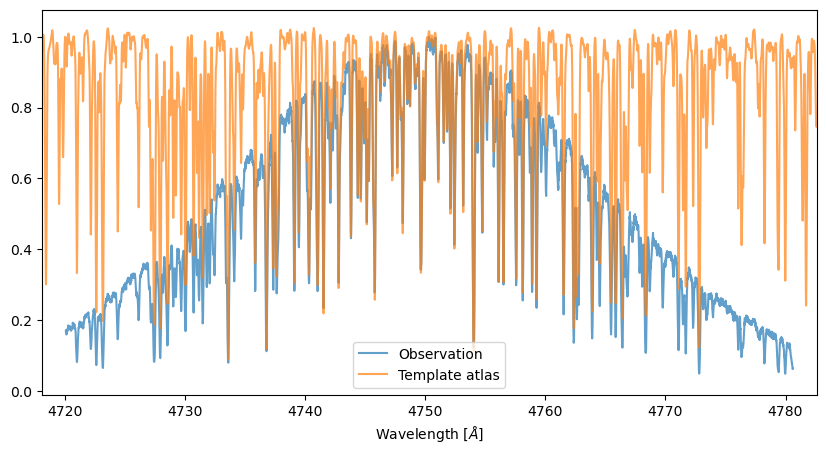

In [12]:
# Calculate Doppler shift of observation
z_obs = obs_velocity / c.value

# Plot this order
plot_order = 15

fig = plt.figure(figsize=(10,5))
plt.plot(obs[plot_order].wave * (1-z_obs), 
         obs[plot_order].flux/np.max(obs[plot_order].flux), alpha=0.7)
plt.plot(ref_wave, ref_flux2, alpha=0.7)
plt.xlim((obs[plot_order].wave * (1-z_obs))[0]-2, (obs[plot_order].wave * (1-z_obs))[-1]+2)
plt.legend(['Observation', 'Template atlas'])
plt.xlabel(r'Wavelength [$\AA$]')
plt.show()


In [13]:
# Calculate Doppler shift of observation
"""z_obs = obs_velocity / c.value
print('Doppler shift of observation: {:.6f}'.format(z_obs))

# Plot this order
plot_order = 21

fig = plt.figure(figsize=(10,5))
plt.plot(jon_wave[plot_order] * (1-z_obs), 
         jon_flux[plot_order]/(response[plot_order]*(np.max(jon_flux[plot_order]))), alpha=0.7)
plt.plot(ref_wave, ref_flux2, alpha=0.7)
plt.xlim((jon_wave[plot_order] * (1-z_obs))[0]-2, (jon_wave[plot_order] * (1-z_obs))[-1]+2)
plt.legend(['Observation', 'Template atlas'])
plt.xlabel(r'Wavelength [$\AA$]')
plt.show()"""

"z_obs = obs_velocity / c.value\nprint('Doppler shift of observation: {:.6f}'.format(z_obs))\n\n# Plot this order\nplot_order = 21\n\nfig = plt.figure(figsize=(10,5))\nplt.plot(jon_wave[plot_order] * (1-z_obs), \n         jon_flux[plot_order]/(response[plot_order]*(np.max(jon_flux[plot_order]))), alpha=0.7)\nplt.plot(ref_wave, ref_flux2, alpha=0.7)\nplt.xlim((jon_wave[plot_order] * (1-z_obs))[0]-2, (jon_wave[plot_order] * (1-z_obs))[-1]+2)\nplt.legend(['Observation', 'Template atlas'])\nplt.xlabel(r'Wavelength [$\\AA$]')\nplt.show()"

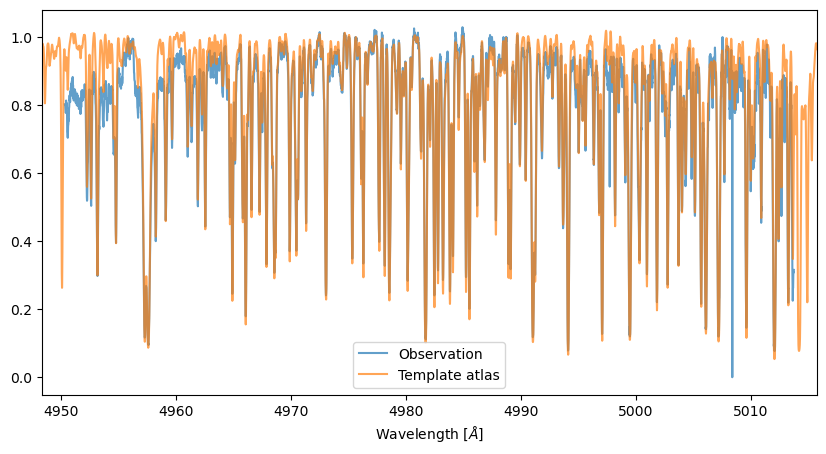

In [14]:
base_path2 = os.path.join(pyodine_path, 'atlas', 'plotcheck')
os.makedirs(base_path2, exist_ok=True)

outname2 = f"{starname}_templatematch_{datefortemplatename}.png"
outpath2 = os.path.join(base_path2, outname2)
# Calculate Doppler shift of observation
z_obs = obs_velocity / c.value

# Plot this order
plot_order = 21
blaze = fit_blaze_spline(obs[plot_order].wave, obs[plot_order].flux)
flux_corr = obs[plot_order].flux / blaze
fig = plt.figure(figsize=(10,5))
plt.plot(obs[plot_order].wave * (1-z_obs), 
         flux_corr, alpha=0.7)


plt.plot(ref_wave, ref_flux2, alpha=0.7)
plt.xlim((obs[plot_order].wave * (1-z_obs))[0]-2, (obs[plot_order].wave * (1-z_obs))[-1]+2)
plt.legend(['Observation', 'Template atlas'])
plt.xlabel(r'Wavelength [$\AA$]')
fig.savefig(outpath2, dpi=300, bbox_inches='tight')
plt.show()

In [15]:
from scipy.signal import savgol_filter
from astropy.modeling import models, fitting

In [16]:
def normalize_spectrum_chunks_safe(wavelength, flux, 
                                   chunk_width=30, 
                                   poly_order=3, 
                                   percentile=90):
    norm_flux = np.full_like(flux, np.nan)
    continuum_model = np.full_like(flux, np.nan)
    
    wl_min = np.min(wavelength)
    wl_max = np.max(wavelength)
    chunk_edges = np.arange(wl_min, wl_max + chunk_width, chunk_width)

    for i in range(len(chunk_edges) - 1):
        start = chunk_edges[i]
        end = chunk_edges[i + 1]
        idx = (wavelength >= start) & (wavelength < end)
        
        if np.sum(idx) < poly_order + 1:
            continue
        
        wl_chunk = wavelength[idx]
        fl_chunk = flux[idx]
        mask = fl_chunk > np.percentile(fl_chunk, percentile)
        
        if np.sum(mask) < poly_order + 1:
            continue
        
        try:
            coeffs = np.polyfit(wl_chunk[mask], fl_chunk[mask], poly_order)
            continuum = np.polyval(coeffs, wl_chunk)
            norm_flux[idx] = fl_chunk / continuum
            continuum_model[idx] = continuum
        except:
            continue

    # Fix: Extrapolate to fill all values
    valid = ~np.isnan(norm_flux)
    interp_flux_func = interp1d(wavelength[valid], norm_flux[valid], bounds_error=False, fill_value='extrapolate')
    interp_cont_func = interp1d(wavelength[valid], continuum_model[valid], bounds_error=False, fill_value='extrapolate')
    
    norm_flux_full = interp_flux_func(wavelength)
    continuum_full = interp_cont_func(wavelength)

    return norm_flux_full, continuum_full

                                          # (None,None) uses all orders
        self.chunk_width = 91                   # Width of chunks in pixels in observation modeling
        self.chunk_padding = 25                 # Padding (left and right) of the chunks in pixels
        self.chunks_per_order = 22              # Maximum number of chunks per order (optional)
        self.pix_offset0 = 30                   # The starting pixel of the first chunk within each order
                         

      self.temp_order_range = (22, 45)         # Order range (min,max) to use in observation modeling;
                                                # (None,None) uses all orders
        self.chunk_width = 120                   # Width of chunks in pixels in observation modeling
        self.chunk_padding = 6                 # Padding (left and right) of the chunks in pixels
        self.chunks_per_order = 22              # Maximum number of chunks per order (optional)
        self.pix_offset0 = 15                   # The starting pixel of the first chunk within each order

 1254 template chunks total.
Skipped 189 chunks total.: {'atlas_range': 189, 'pix_oob': 0, 'empty_ref': 0}


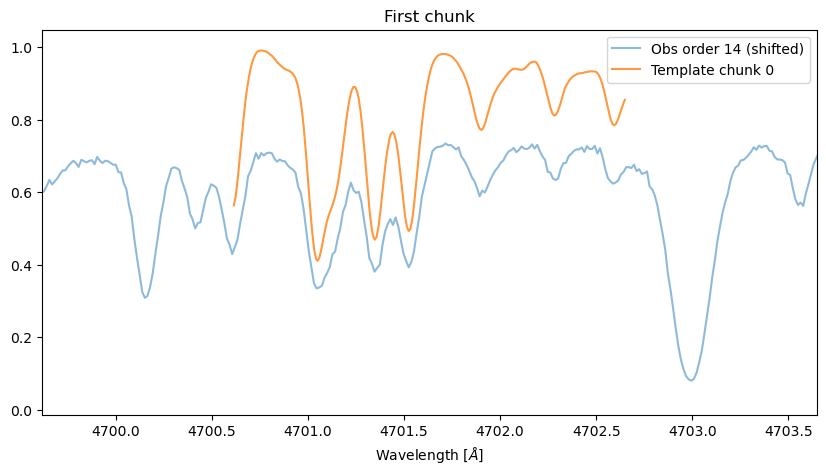

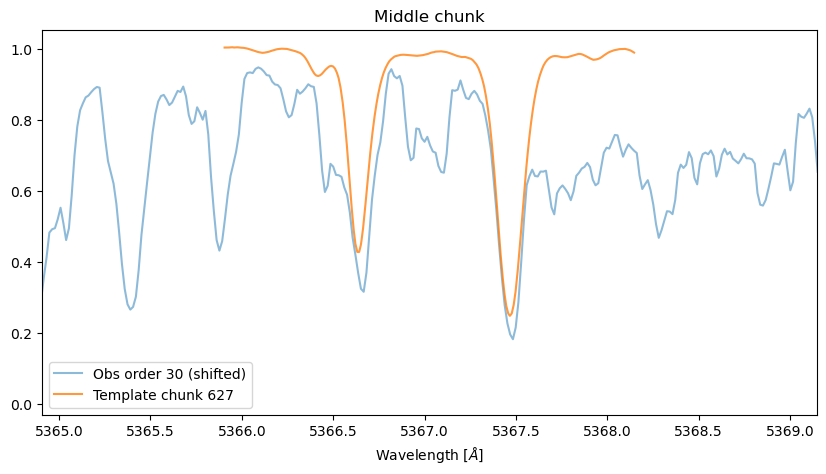

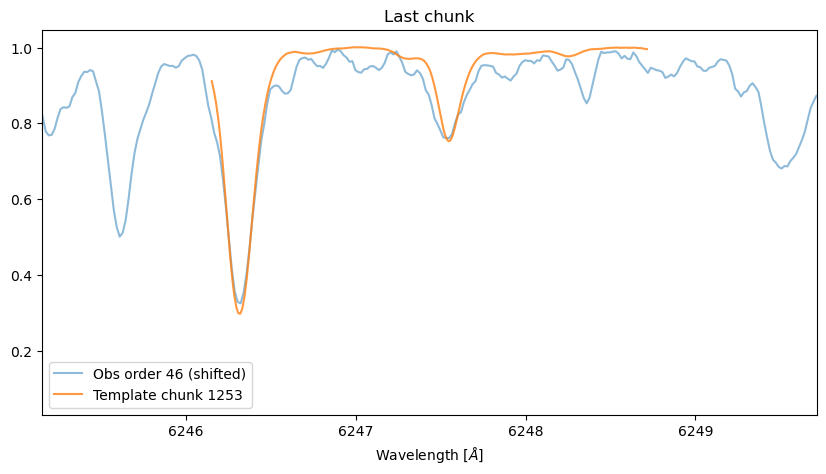

In [17]:
pix_offset0        = 15     # start chunking from this pixel
chunk_width        = 120    # width of the chunks in pixels (OBS pixels)
chunk_padding      = 15     # nominal padding (OBS pixels)
temp_oversampling  = 10     # oversampling of template relative to OBS sampling
chunks_per_order   = 39     # desired chunks per order (target)

# --- Diagnostics / bookkeeping ---
template_chunks = []
skipped_chunks = 0
skipped_reason_counts = {"atlas_range": 0, "pix_oob": 0, "empty_ref": 0}

# Loop through the orders defined above
for o in range(first_order + order_correction, last_order + order_correction + 1):
    # derive order length from data (do NOT hardcode 4800)
    npix_spec = len(obs[o].wave)

    # Maximum chunks per order without order-edge correction
    max_chunks_per_order = int((npix_spec - 2 * chunk_padding) / chunk_width)
    if chunks_per_order > max_chunks_per_order:
        print(f"Warning (order {o}): Max chunks without cutting is {max_chunks_per_order}, "
              f"requested {chunks_per_order}. Edge correction will trigger.")

    obs_ch_endpix = pix_offset0

    for i in range(chunks_per_order):

        # --- Build pixel index array for this chunk (with padding) ---
        if obs_ch_endpix + chunk_width + chunk_padding > npix_spec:
            # Edge case: reduce padding to stay within order
            padding2 = npix_spec - (obs_ch_endpix + chunk_width)
            if padding2 < 0:
                # Can't even fit the core width -> stop chunking this order
                skipped_chunks += 1
                skipped_reason_counts["pix_oob"] += 1
                break
            obs_ch_pix = obs_ch_endpix + np.arange(-padding2, chunk_width + padding2)
        else:
            padding2 = chunk_padding
            obs_ch_pix = obs_ch_endpix + np.arange(-chunk_padding, chunk_width + chunk_padding)

        # Enforce pixel bounds explicitly (prevents negative wrap-around)
        obs_ch_pix = obs_ch_pix[(obs_ch_pix >= 0) & (obs_ch_pix < npix_spec)]
        if len(obs_ch_pix) < 3:
            skipped_chunks += 1
            skipped_reason_counts["pix_oob"] += 1
            break

        # Update pointer CONSISTENTLY with the actual padding used (padding2)
        obs_ch_endpix = obs_ch_pix[-1] - padding2 + 1

        obs_ch_wave = obs[o].wave[obs_ch_pix]
        if obs_ch_wave[0] > obs_ch_wave[-1]:
            # Standardize direction for subsequent min/max logic
            obs_ch_wave = obs_ch_wave[::-1]

        # --- Select corresponding region in reference atlas (robust to direction) ---
        w_lo = obs_ch_wave.min()
        w_hi = obs_ch_wave.max()

        # Guard: atlas must cover this chunk’s wavelength span
        if (w_lo < ref_wave.min()) or (w_hi > ref_wave.max()):
            skipped_chunks += 1
            skipped_reason_counts["atlas_range"] += 1
            continue

        ref_ch_pix_start = np.argmin(np.abs(w_lo - ref_wave))
        ref_ch_pix_end   = np.argmin(np.abs(w_hi - ref_wave))
        if ref_ch_pix_end < ref_ch_pix_start:
            ref_ch_pix_start, ref_ch_pix_end = ref_ch_pix_end, ref_ch_pix_start

        ref_ch_pix  = np.arange(ref_ch_pix_start, ref_ch_pix_end + 1)
        if len(ref_ch_pix) < 3:
            skipped_chunks += 1
            skipped_reason_counts["empty_ref"] += 1
            continue

        ref_ch_wave = ref_wave[ref_ch_pix]
        ref_ch_flux = ref_flux2[ref_ch_pix]

        # --- Rebin reference chunk onto oversampled “template pixel” grid ---
        chunk_length = (chunk_width - 1 + 2 * padding2) * temp_oversampling + 1

        # Build a "fine grid" in reference-index space, then rebin
        temp_ch_pix  = np.linspace(ref_ch_pix[0], ref_ch_pix[-1], chunk_length)
        temp_ch_wave = pyodine.lib.misc.rebin(ref_ch_pix, ref_ch_wave, temp_ch_pix)
        temp_ch_flux = pyodine.lib.misc.rebin(ref_ch_pix, ref_ch_flux, temp_ch_pix)

        # --- Wavelength model parameters for the oversampled template chunk ---
        n = len(temp_ch_pix)
        p = np.polyfit(np.arange(-(n // 2), n - n // 2), temp_ch_wave, 1)
        temp_ch_w0 = p[1]
        temp_ch_w1 = p[0]

        # --- Chunk weights ---
        chunk_weights = pyodine.lib.misc.analytic_chunk_weights(temp_ch_flux, temp_ch_w0, temp_ch_w1)

        # Metadata for TemplateChunk
        pix0  = int(obs_ch_pix[0] + padding2)               # first “core” pixel in OBS coordinates
        order = int(o)
        w0    = float(temp_ch_w0)
        w1    = float(temp_ch_w1 * temp_oversampling)       # scale to oversampled grid

        # Fine pixel grid stored in TemplateChunk (in OBS pixel coordinates)
        pix_fine = np.linspace(obs_ch_pix[0], obs_ch_pix[-1], chunk_length)

        temp_chunk = pyodine.components.TemplateChunk(
            temp_ch_flux, temp_ch_wave, pix_fine, w0, w1, order, pix0, chunk_weights
        )
        template_chunks.append(temp_chunk)

print(f" {len(template_chunks)} template chunks total.")
print(f"Skipped {skipped_chunks} chunks total.: {skipped_reason_counts}")


z_obs = obs_velocity / c.value

def plot_chunk_overlay(template_chunks, idx, title=None):
    ch = template_chunks[idx]
    o  = ch.order
    fig = plt.figure(figsize=(10, 5))
    # OBS overlay (normalize roughly for display)
    obs_wave = obs[o].wave * (1 - z_obs)
    obs_flux = obs[o].flux / np.nanmax(obs[o].flux)
    plt.plot(obs_wave, obs_flux, alpha=0.5, label=f'Obs order {o} (shifted)')
    plt.plot(ch.wave, ch.flux, alpha=0.8, label=f'Template chunk {idx}')
    plt.xlim(ch.wave[0] - 1.0, ch.wave[-1] + 1.0)
    plt.xlabel(r'Wavelength [$\AA$]')
    plt.legend()
    if title is not None:
        plt.title(title)
    plt.show()

if len(template_chunks) >= 1:
    first_idx = 0
    mid_idx   = len(template_chunks) // 2
    last_idx  = len(template_chunks) - 1

    plot_chunk_overlay(template_chunks, first_idx, title="First chunk")
    plot_chunk_overlay(template_chunks, mid_idx,   title="Middle chunk")
    plot_chunk_overlay(template_chunks, last_idx,  title="Last chunk")
else:
    print("PROBLEMS IN CHUNK COVERAGE CHECK THE ATLAS!!!.")

Length of template chunk (oversampled): 1491


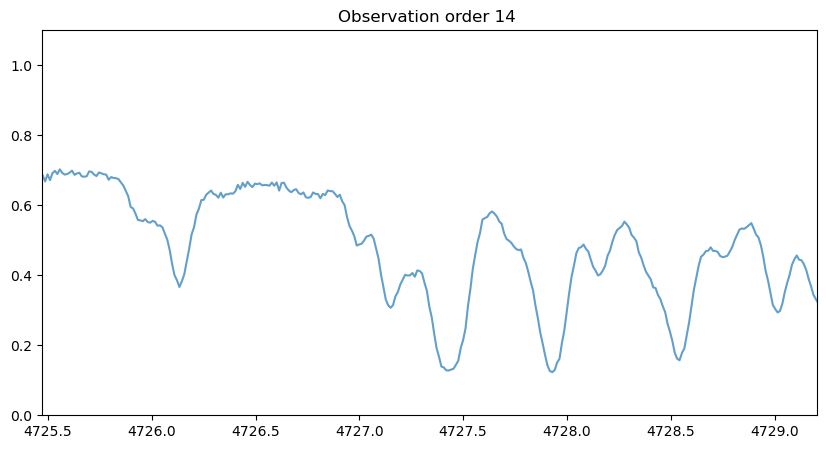

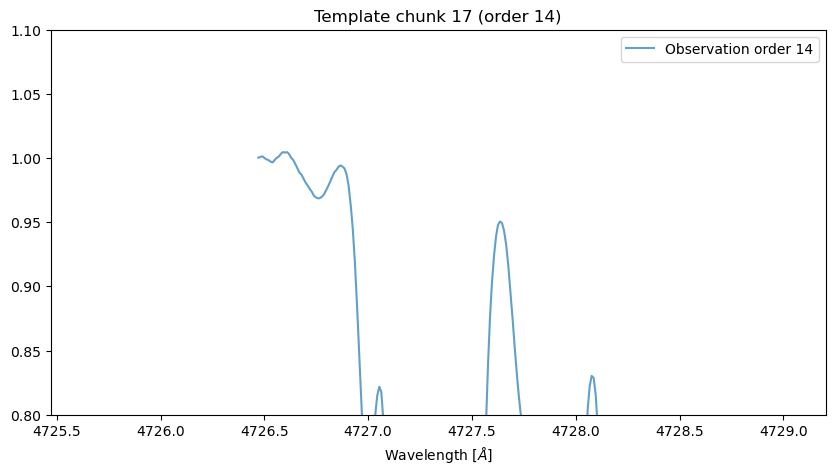

In [18]:
# Overplot template chunk to check
plot_chunk = 17
plot_order = first_order + order_correction

print('Length of template chunk (oversampled):', len(template_chunks[plot_chunk].flux))

fig = plt.figure(figsize=(10,5))
plt.plot(obs[plot_order].wave * (1-z_obs), 
         obs[plot_order].flux/np.max(obs[plot_order].flux), alpha=0.7)
plt.xlim(template_chunks[plot_chunk].wave[0]-1, template_chunks[plot_chunk].wave[-1]+1)
plt.ylim(0.0, 1.1)
plt.title('Observation order {} '.format(plot_order, plot_chunk))
plt.show()
plt.figure(figsize=(10,5))
plt.plot(template_chunks[plot_chunk].wave, template_chunks[plot_chunk].flux, alpha=0.7)
plt.xlim(template_chunks[plot_chunk].wave[0]-1, template_chunks[plot_chunk].wave[-1]+1)
plt.legend(['Observation order {}'.format(plot_order), 
            'Template chunk {}'.format(plot_chunk)])
plt.ylim(0.8, 1.1)
plt.xlabel(r'Wavelength [$\AA$]')
plt.title('Template chunk {} (order {})'.format(plot_chunk, plot_order))
plt.show()

Length of template chunk (oversampled): 1491


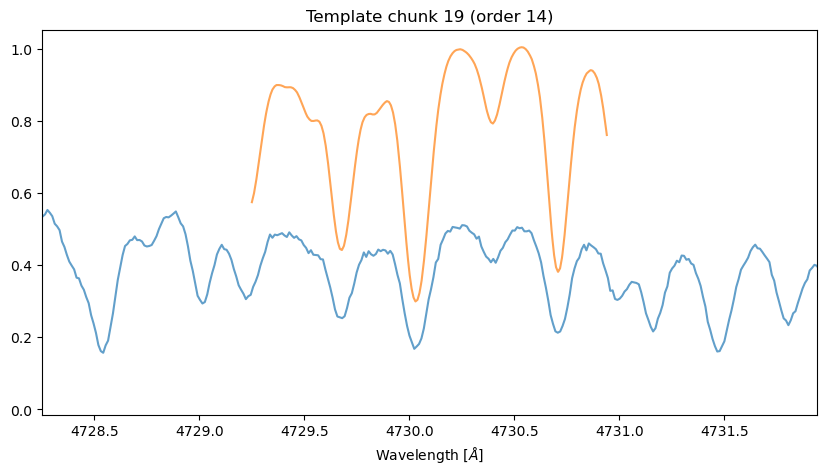

In [19]:
# Overplot template chunk to check
plot_chunk = 19
plot_order = first_order + order_correction

print('Length of template chunk (oversampled):', len(template_chunks[plot_chunk].flux))

fig = plt.figure(figsize=(10,5))
plt.plot(obs[plot_order].wave * (1-z_obs), 
         obs[plot_order].flux/np.max(obs[plot_order].flux), alpha=0.7)

plt.plot(template_chunks[plot_chunk].wave, template_chunks[plot_chunk].flux, alpha=0.7)
plt.xlim(template_chunks[plot_chunk].wave[0]-1, template_chunks[plot_chunk].wave[-1]+1)
#plt.ylim(0.2, 1.1)
plt.xlabel(r'Wavelength [$\AA$]')
plt.title('Template chunk {} (order {})'.format(plot_chunk, plot_order))
plt.show()

In [20]:
# Pack the template into a HDF5-file as compatible with StellarTemplate_Chunked object
# This is not really important - but I always put in the time of template creation
date = Time.now()

base_filename = f"{atlas}_{starname}_atlas_{datefortemplatename}.h5"
base_path = os.path.join(pyodine_path, 'atlas')
os.makedirs(base_path, exist_ok=True)


temp_filepath = os.path.join(base_path, base_filename)

# If file exists, increment version number
if os.path.exists(temp_filepath):
    version = 1
    while True:
        versioned_filename = (
            f"{atlas}_{starname}_atlas_{datefortemplatename}_v{version:03d}.h5"
        )
        versioned_path = os.path.join(base_path, versioned_filename)
        if not os.path.exists(versioned_path):
            temp_filepath = versioned_path
            break
        version += 1

with h5py.File(temp_filepath, 'w') as h:
    h.create_dataset('/orig_filename', data=temp_filepath)
    h.create_dataset('/starname', data=starname)
    h.create_dataset('/time_start', data=date.isot)
    h.create_dataset('/velocity_offset', data=arc_velocity)
    # The barycentric velocity of the reference spectrum is 0.
    h.create_dataset('/bary_vel_corr', data=0.)
    h.create_dataset('/osample', data=temp_oversampling)
    h.create_dataset('/orders', data=np.array([c.order for c in template_chunks]))
    h.create_dataset('/pix0', data=np.array([c.pix0 for c in template_chunks]))
    h.create_dataset('/weight', data=np.array([c.weight for c in template_chunks]))
    h.create_dataset('/w0', data=np.array([c.w0 for c in template_chunks]))
    h.create_dataset('/w1', data=np.array([c.w1 for c in template_chunks]))

    for i in range(len(template_chunks)):
        grp = '/chunks/{}/'.format(i)
        h.create_dataset(grp + 'flux', data=template_chunks[i].flux)
        h.create_dataset(grp + 'wave', data=template_chunks[i].wave)
        h.create_dataset(grp + 'pixel', data=template_chunks[i].pixel)
        
        
#print filename create
print(f'I created this file: {temp_filepath}')

I created this file: /Users/jaklusmeyer/SONG/pyodine/atlas/Pepsi_Arcturus_atlas_260217.h5


Loading template from file: /Users/jaklusmeyer/SONG/pyodine/atlas/Pepsi_Arcturus_atlas_260217.h5


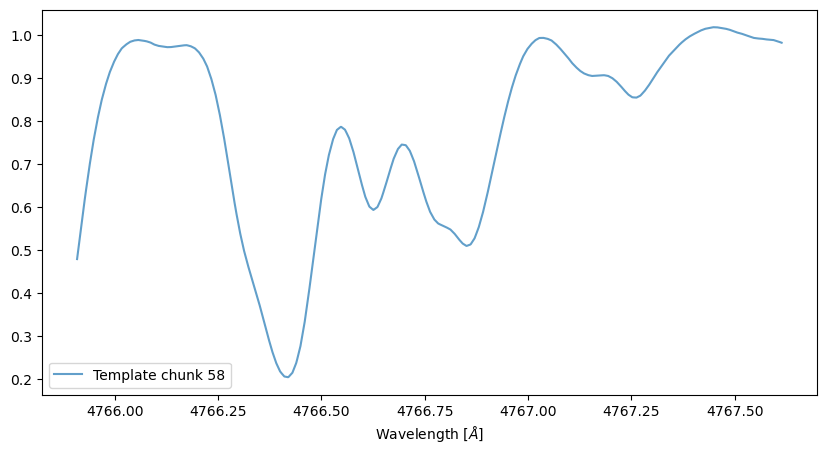

1.7045268207612025


In [21]:
# Test if it can be loaded
arcturus_temp = pyodine.template.base.StellarTemplate_Chunked(temp_filepath)

# Plot template chunk to check 9-
plot_chunk =58


fig = plt.figure(figsize=(10,5))
plt.plot(arcturus_temp[plot_chunk].wave, arcturus_temp[plot_chunk].flux, alpha=0.7)
plt.legend(['Template chunk {}'.format(plot_chunk)])
plt.xlabel(r'Wavelength [$\AA$]')
plt.show()
print(np.max(arcturus_temp[plot_chunk].wave)-np.min(arcturus_temp[plot_chunk].wave))

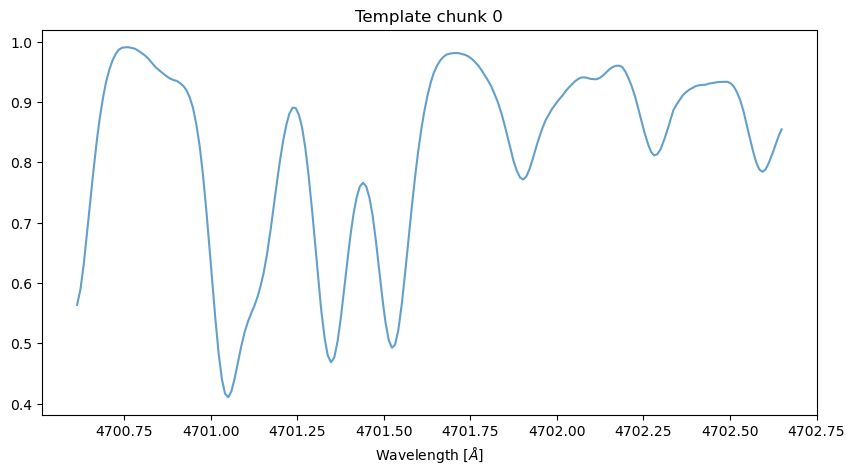

2.0362157705048958 wavelength chunk A


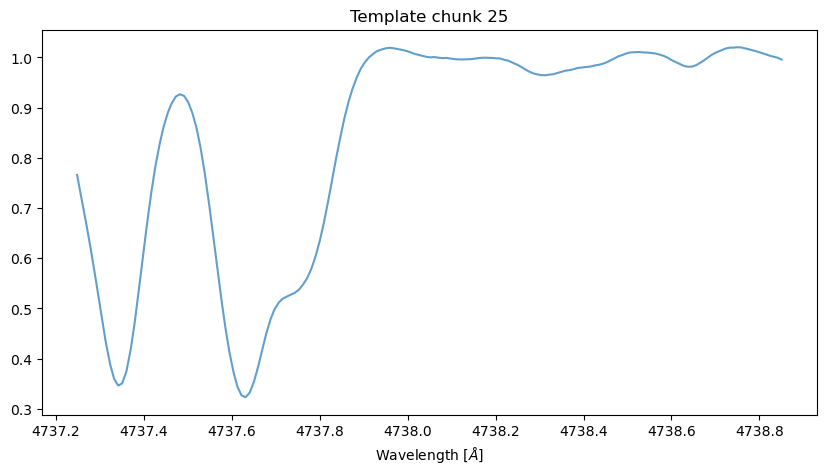

1.6022894723528225 wavelength chunk A


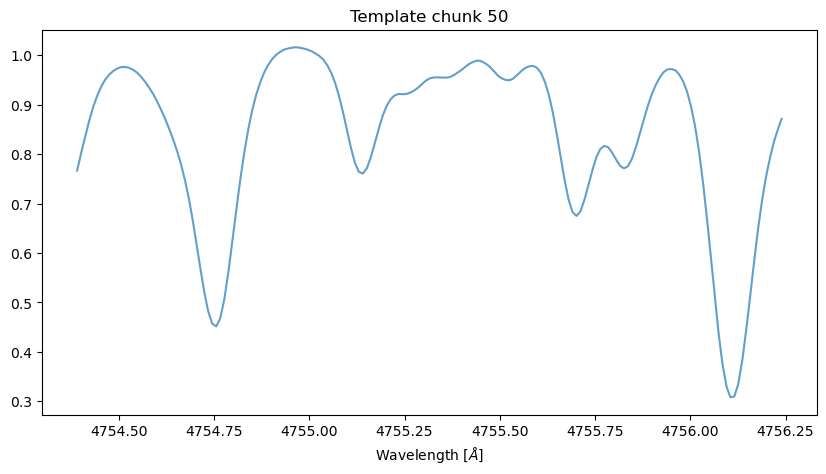

1.8496036954220472 wavelength chunk A


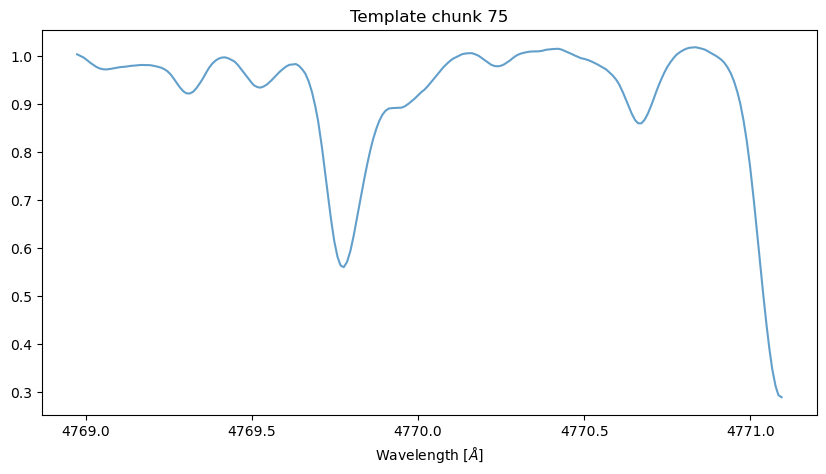

2.1192268667446115 wavelength chunk A


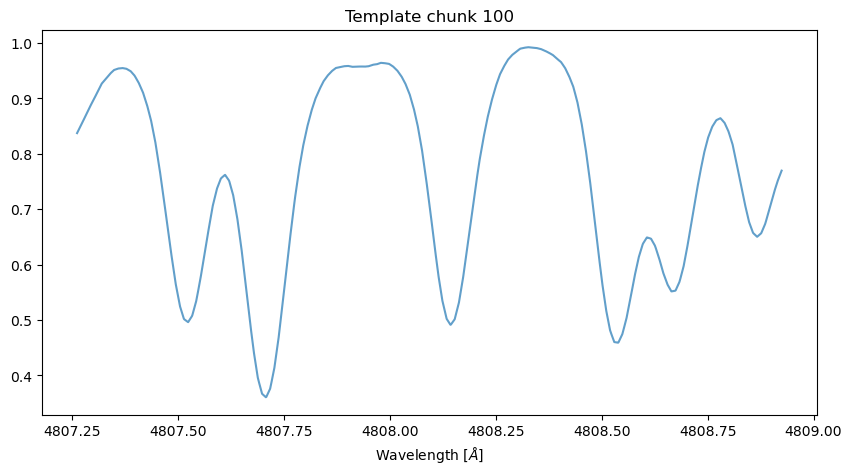

1.6632441576457495 wavelength chunk A


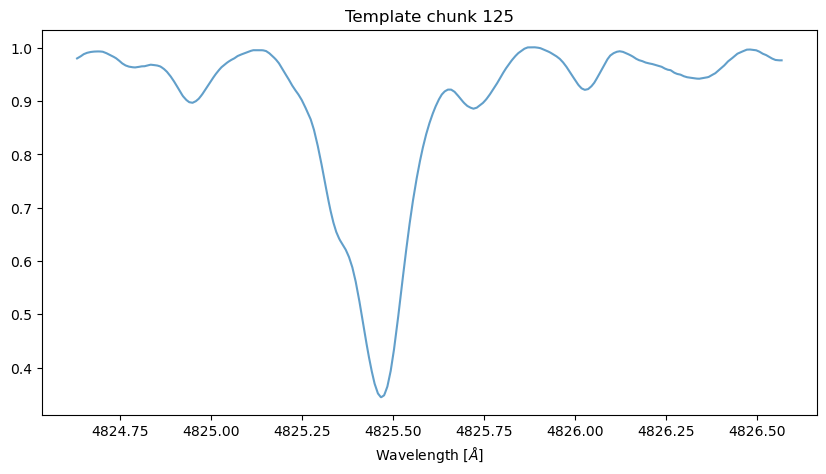

1.9342180492167245 wavelength chunk A


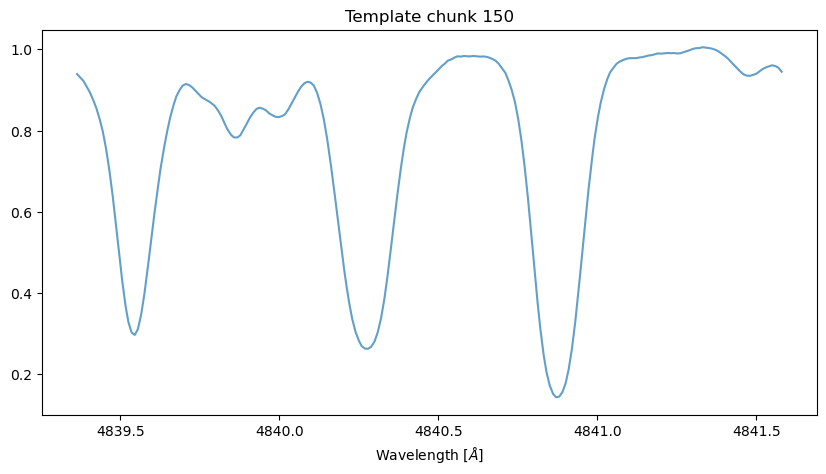

2.215444939007284 wavelength chunk A


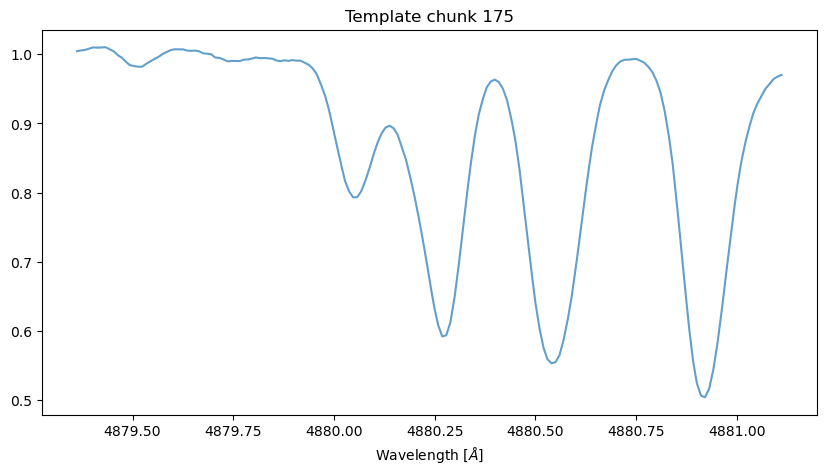

1.748643229141635 wavelength chunk A


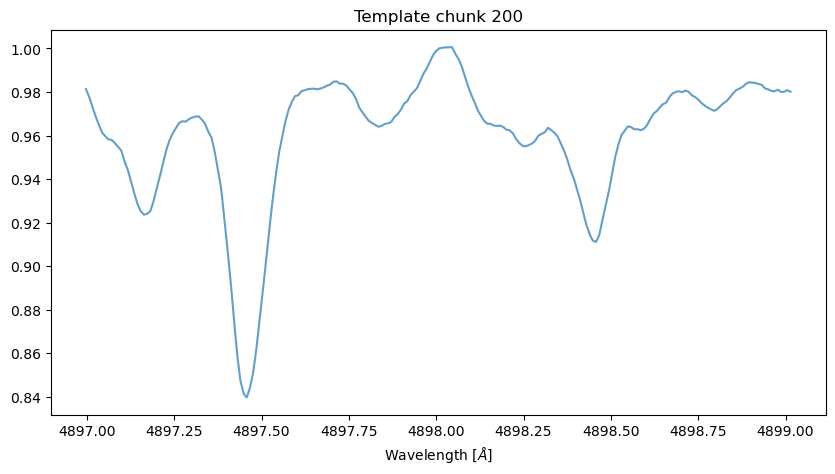

2.0166588595257053 wavelength chunk A


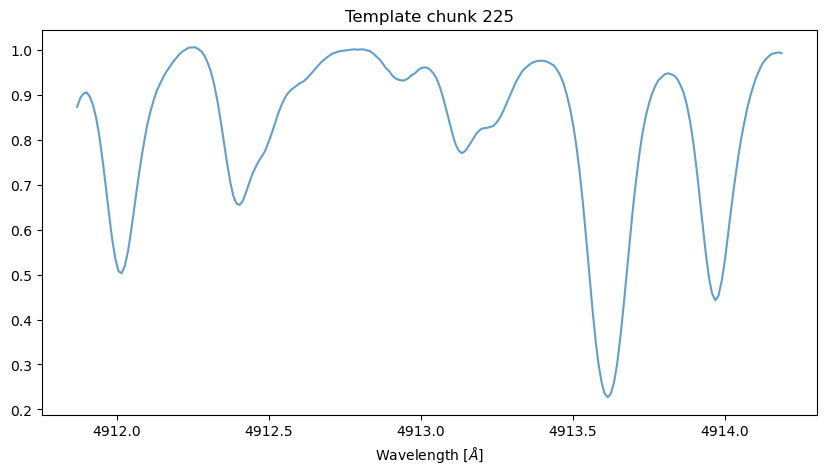

2.3163734674953957 wavelength chunk A


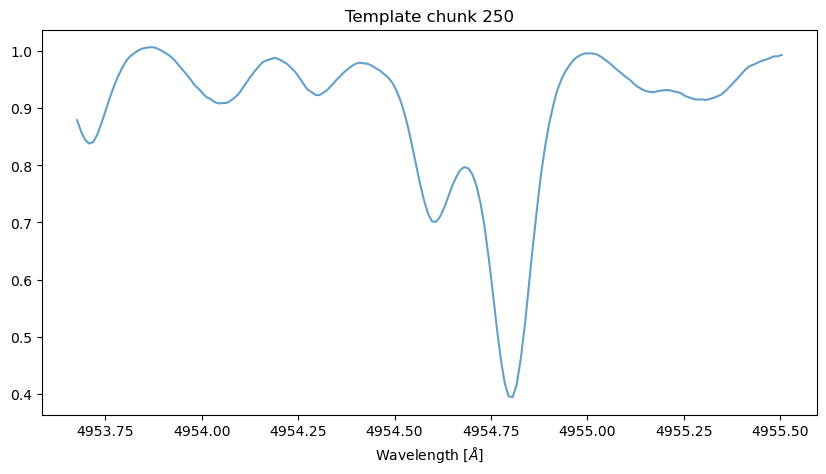

1.8271383345490904 wavelength chunk A


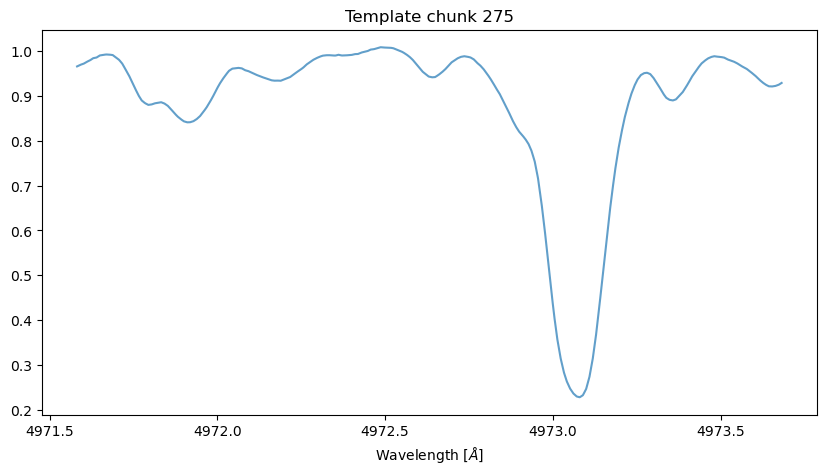

2.1005192409511437 wavelength chunk A


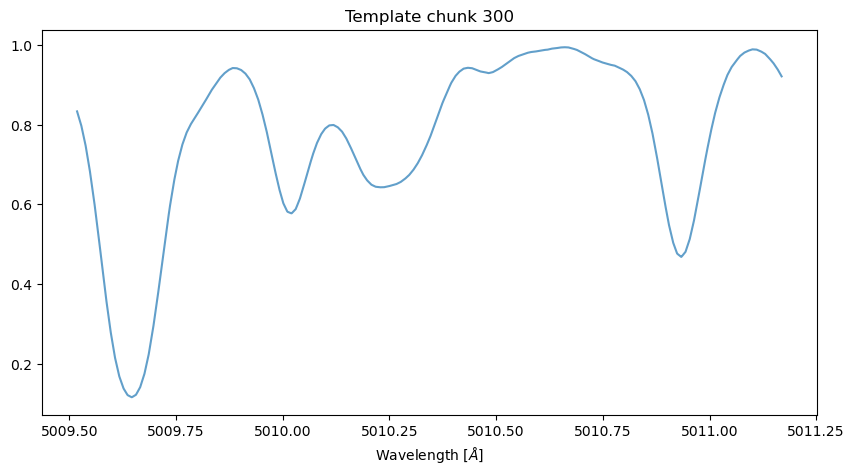

1.6509016620893817 wavelength chunk A


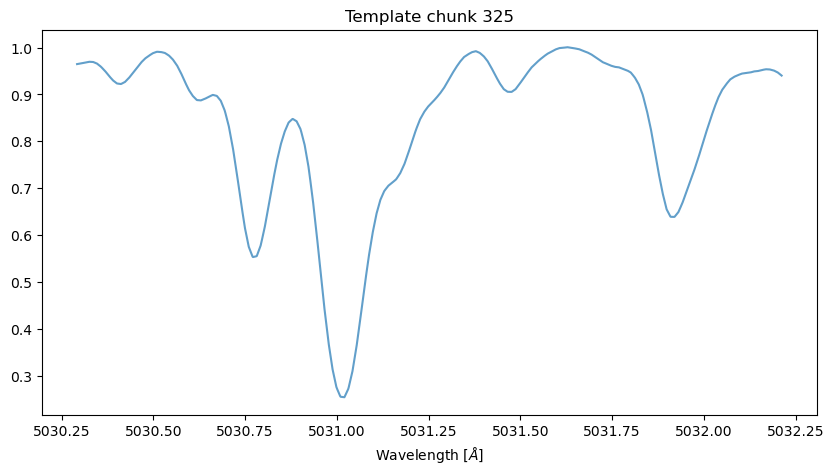

1.9196640113823378 wavelength chunk A


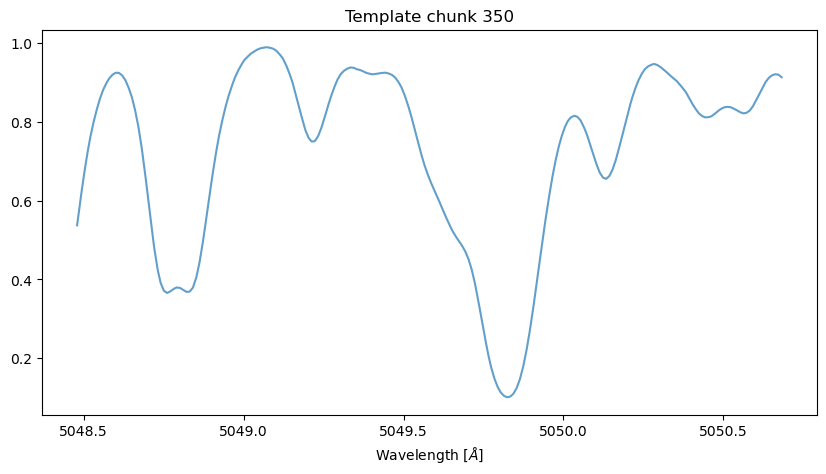

2.203399533580523 wavelength chunk A


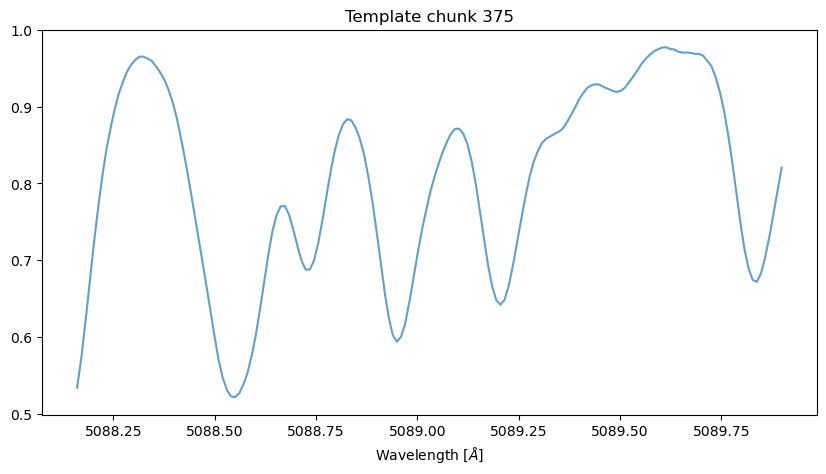

1.7379192884764052 wavelength chunk A


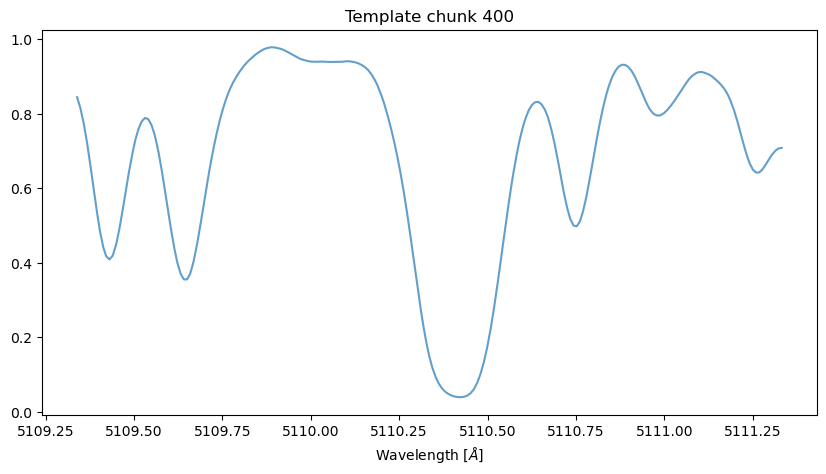

1.9931566911172922 wavelength chunk A


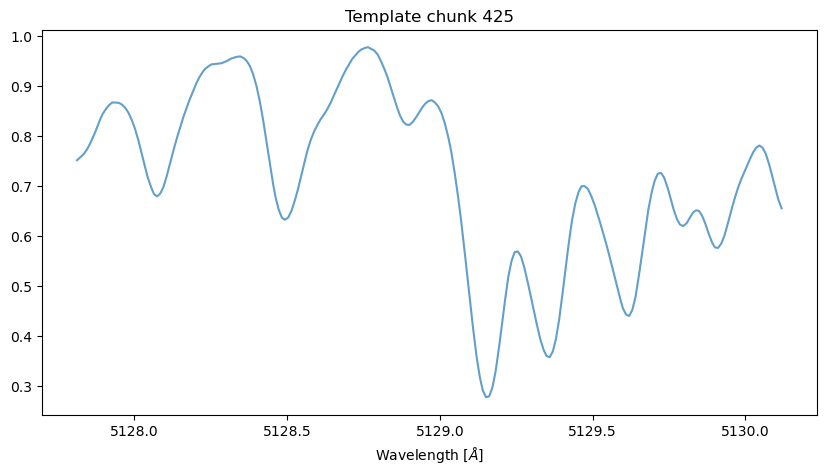

2.3065168236889804 wavelength chunk A


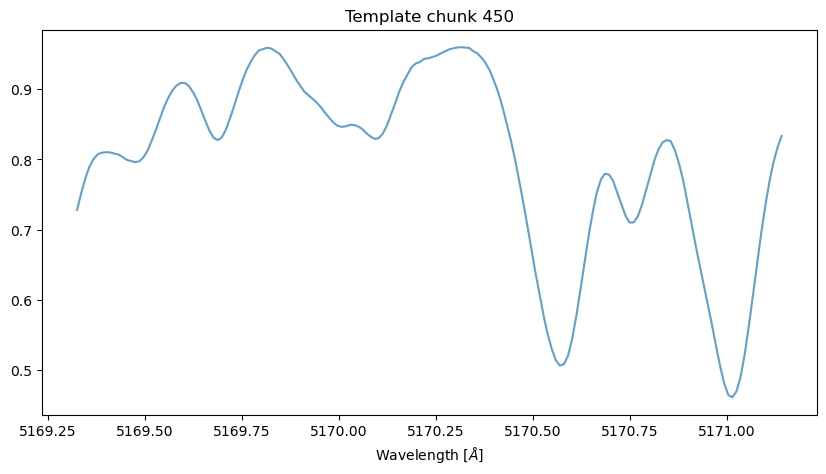

1.8160638512745209 wavelength chunk A


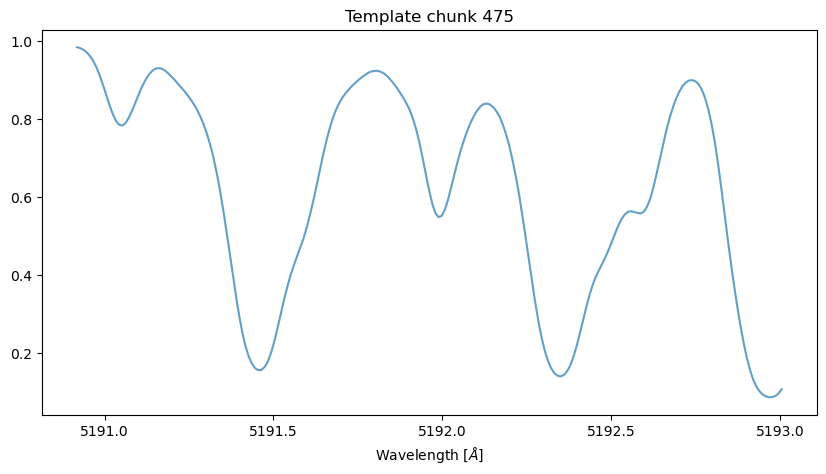

2.086343616171689 wavelength chunk A


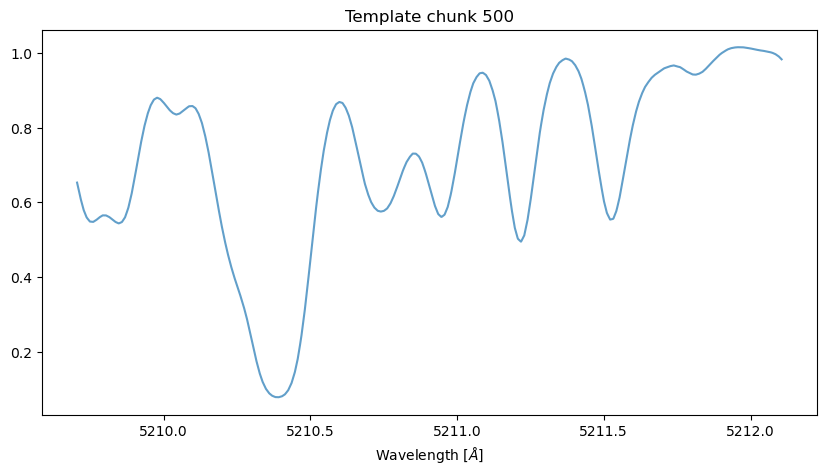

2.4009653856792283 wavelength chunk A


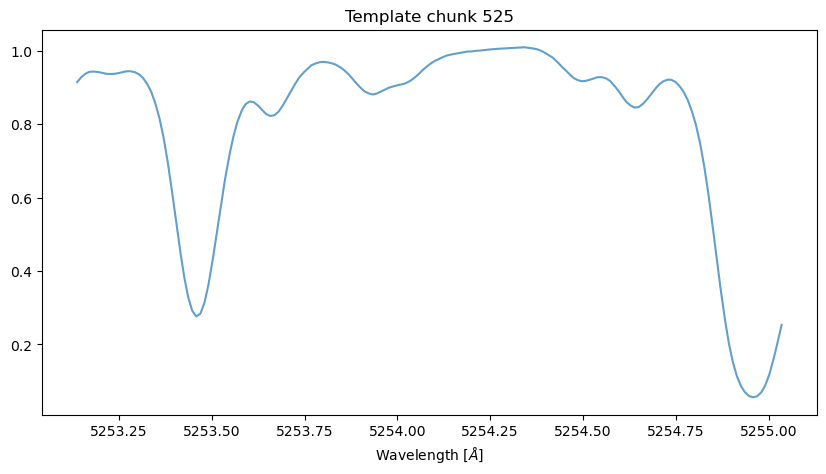

1.8973944249173655 wavelength chunk A


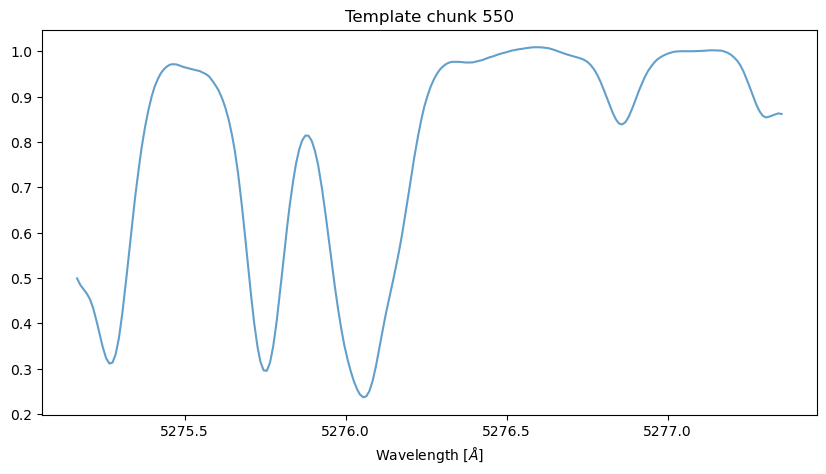

2.1885413251948194 wavelength chunk A


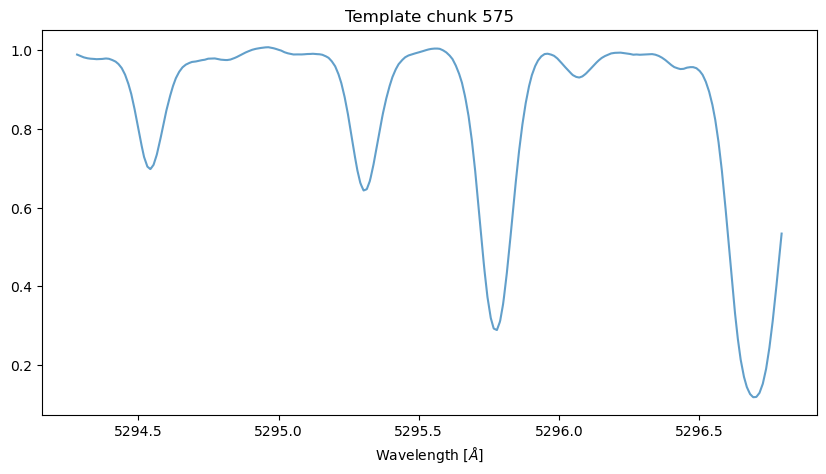

2.513508489484593 wavelength chunk A


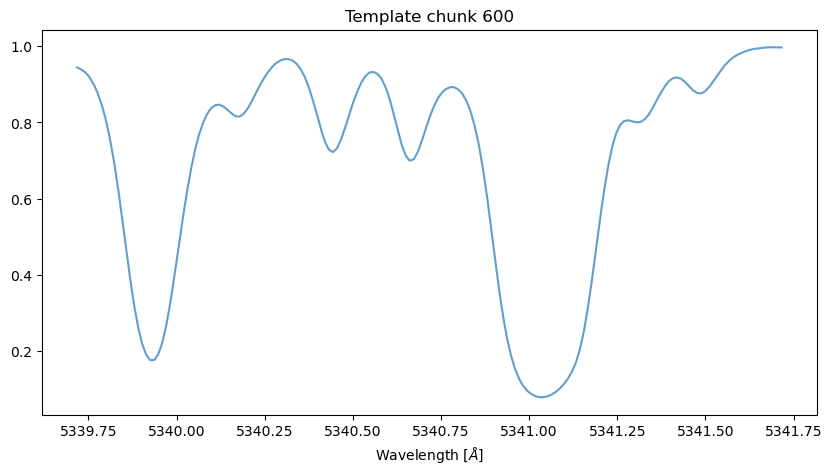

1.9982841597238803 wavelength chunk A


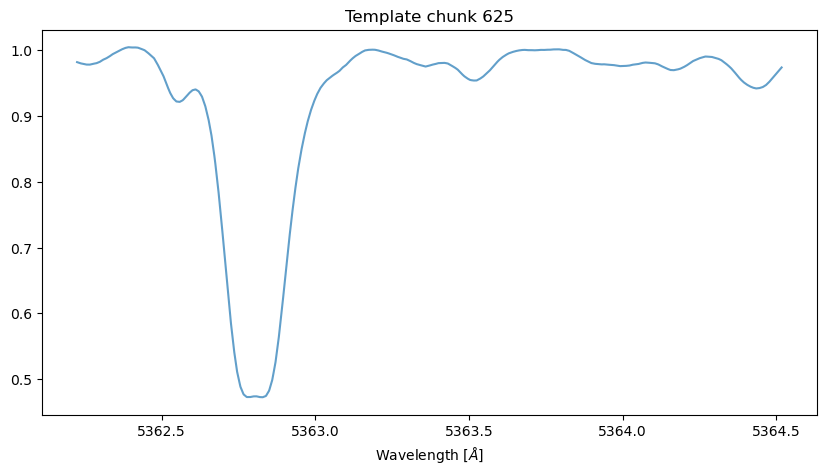

2.2931337189120313 wavelength chunk A


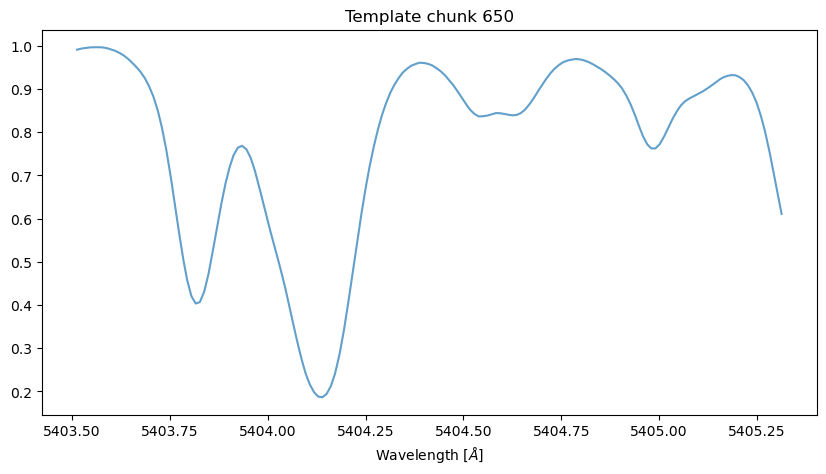

1.8006926391135494 wavelength chunk A


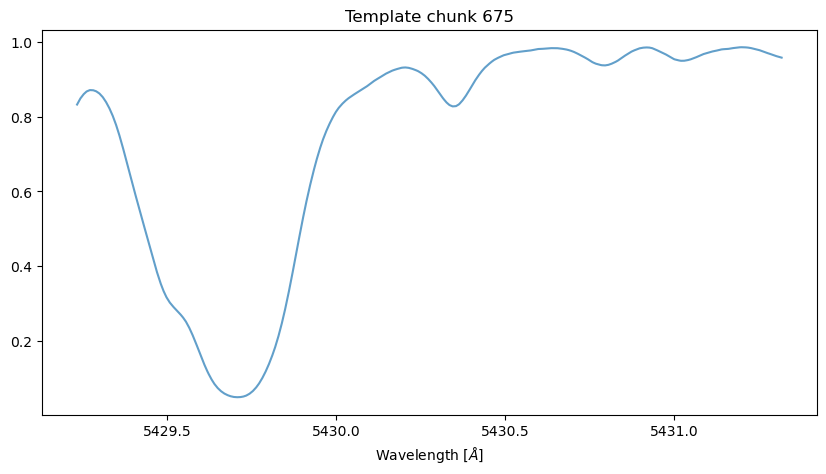

2.085096840756705 wavelength chunk A


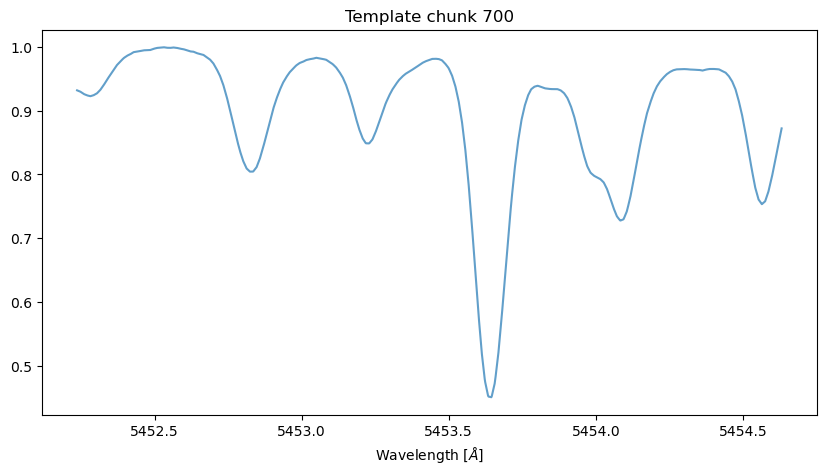

2.39553145750142 wavelength chunk A


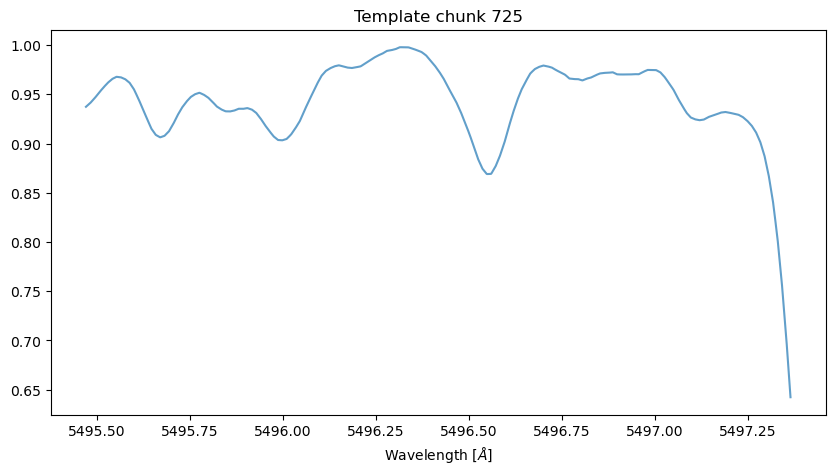

1.8924875745105965 wavelength chunk A


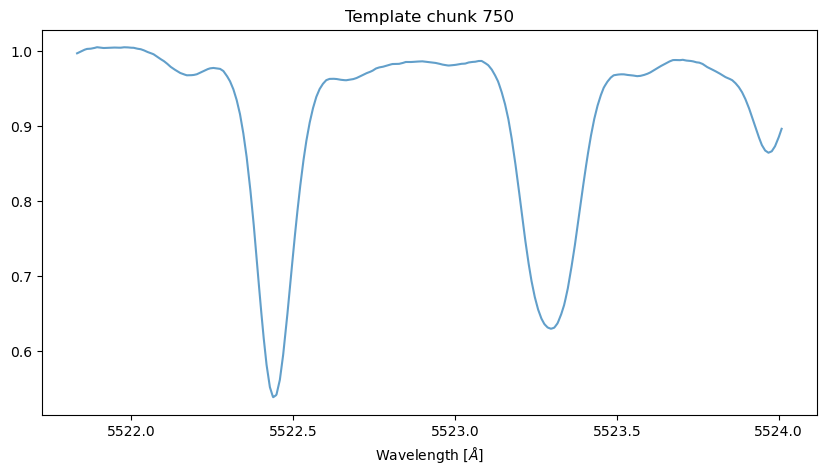

2.1765580302517264 wavelength chunk A


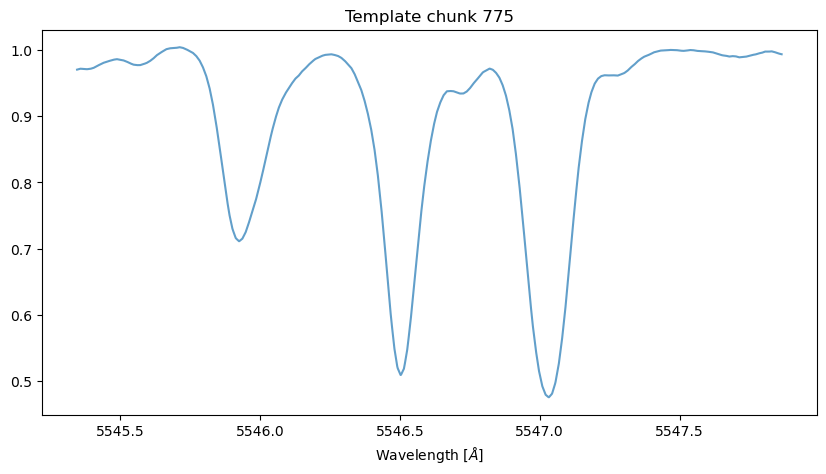

2.519244313936724 wavelength chunk A


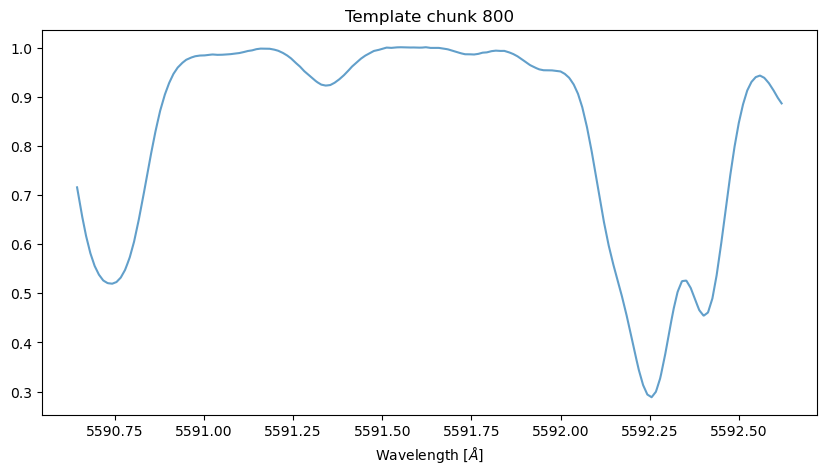

1.9764027079236257 wavelength chunk A


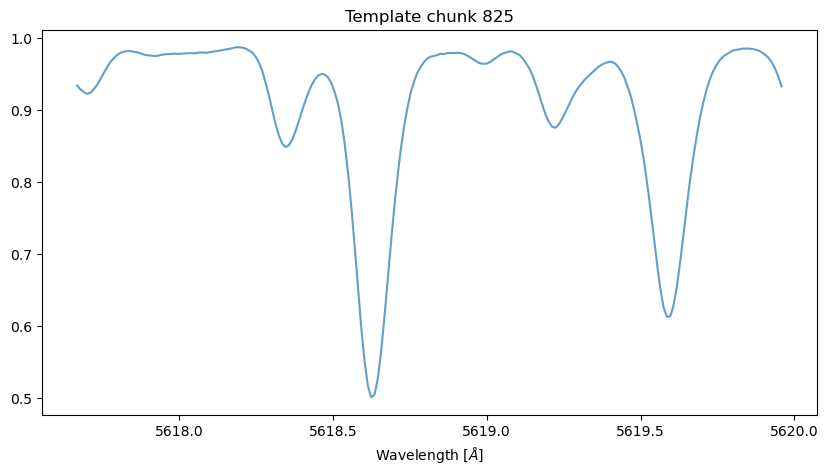

2.2905713596655914 wavelength chunk A


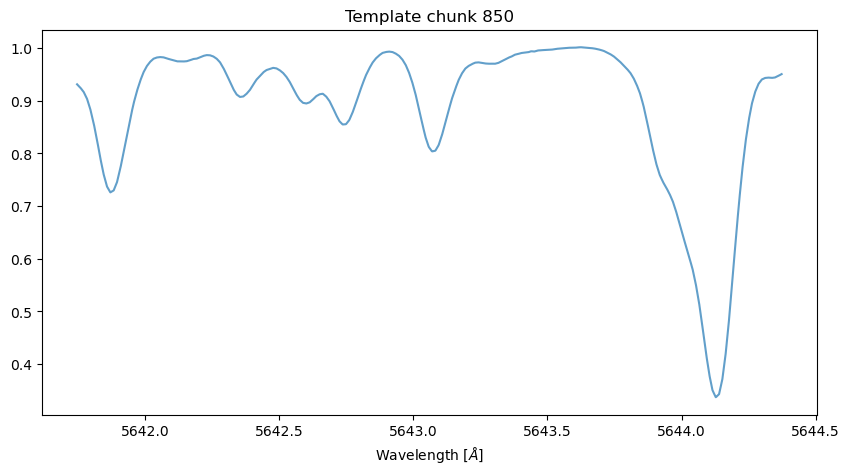

2.625930501001676 wavelength chunk A


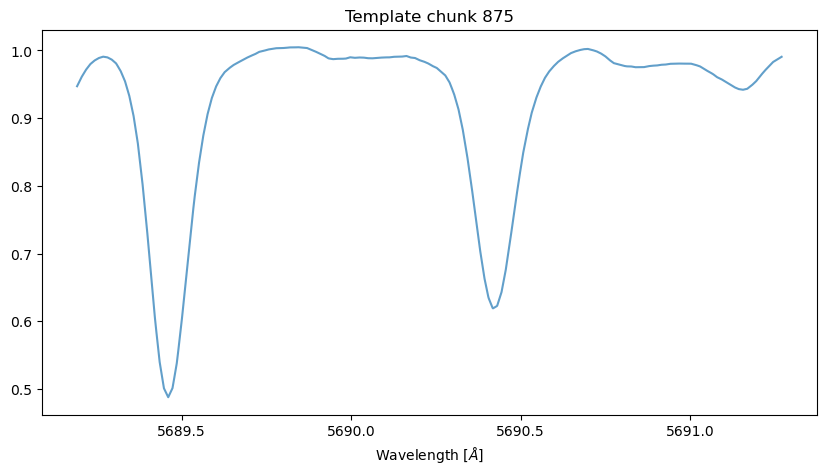

2.0783057540238588 wavelength chunk A


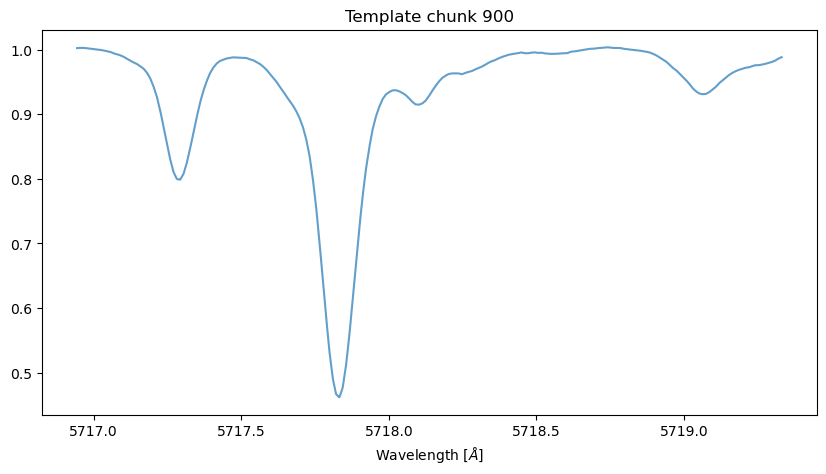

2.3881146459580123 wavelength chunk A


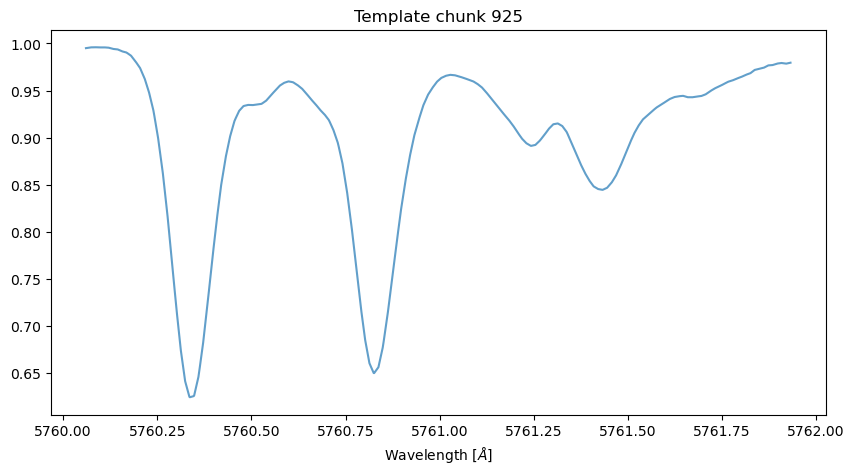

1.8717794314234197 wavelength chunk A


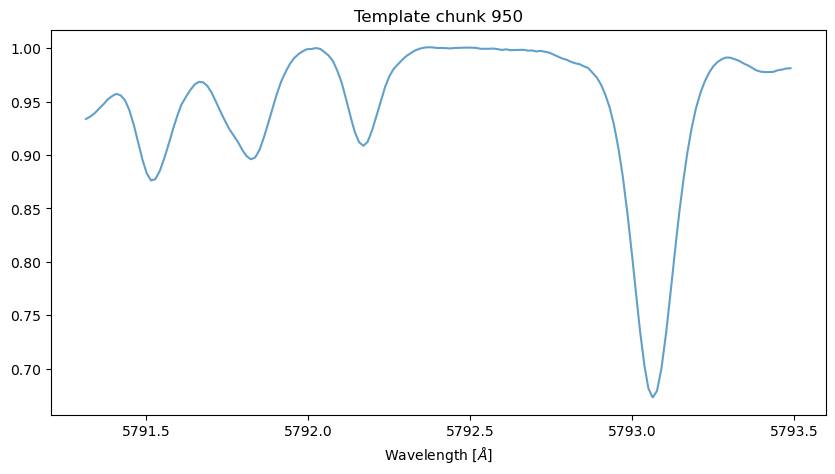

2.173763932395559 wavelength chunk A


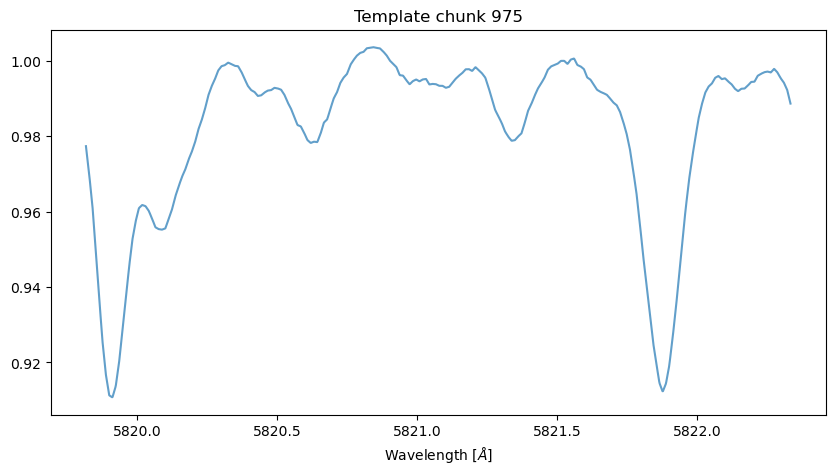

2.5136042356807593 wavelength chunk A


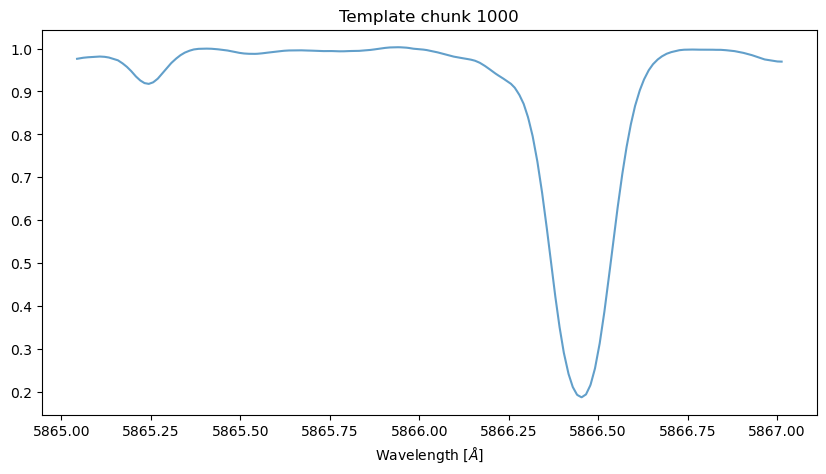

1.9685051158530769 wavelength chunk A


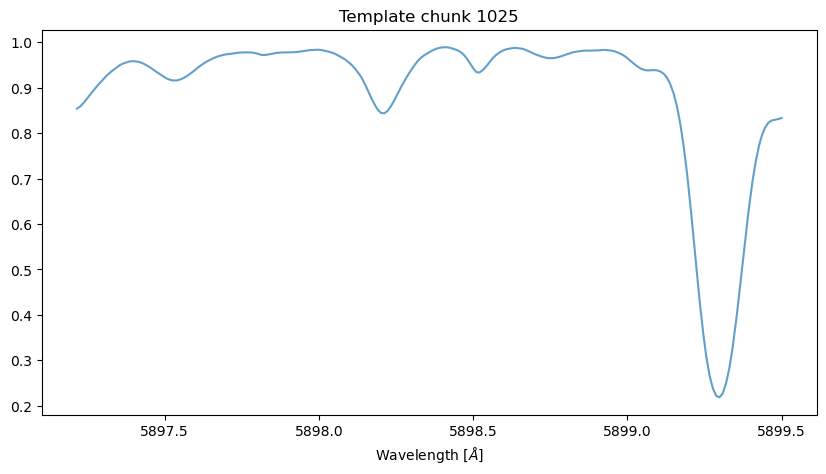

2.284152389692281 wavelength chunk A


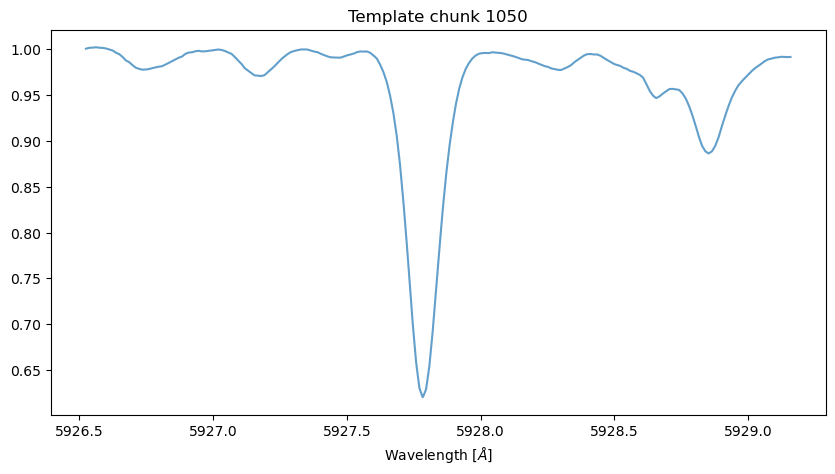

2.6339734425519055 wavelength chunk A


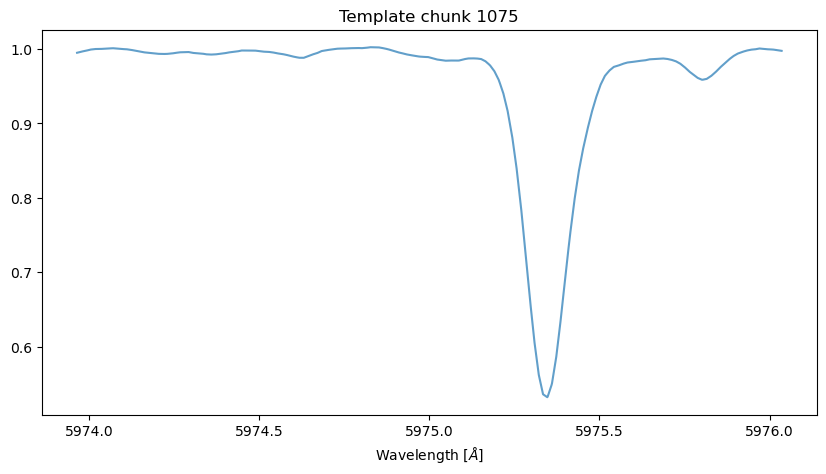

2.0713089306127586 wavelength chunk A


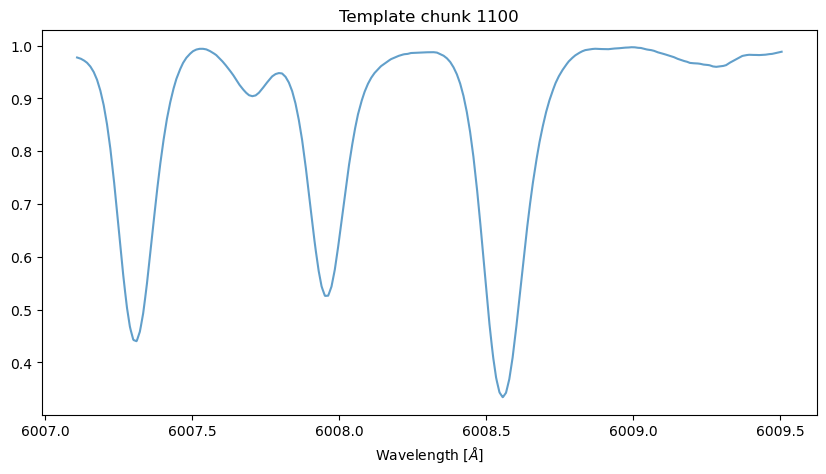

2.395129363727392 wavelength chunk A


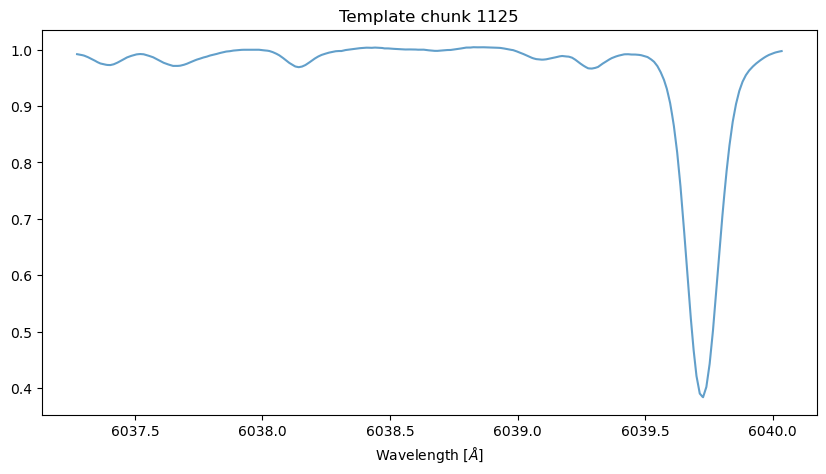

2.7611818694977046 wavelength chunk A


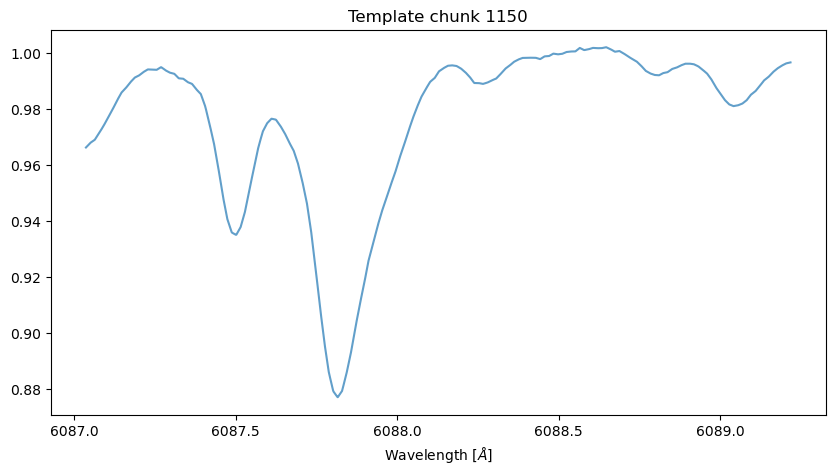

2.1811971499728315 wavelength chunk A


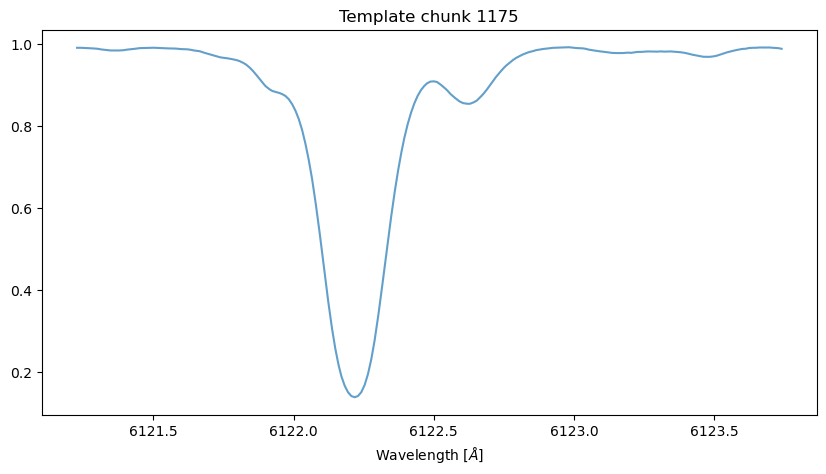

2.51185472101497 wavelength chunk A


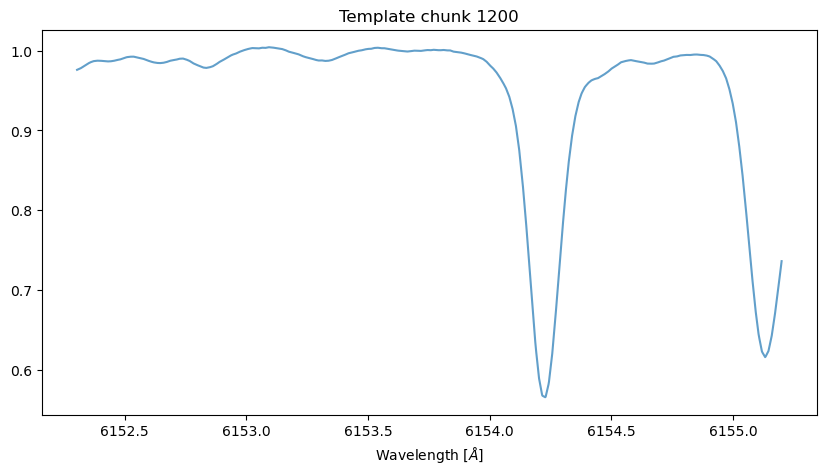

2.896365167656768 wavelength chunk A


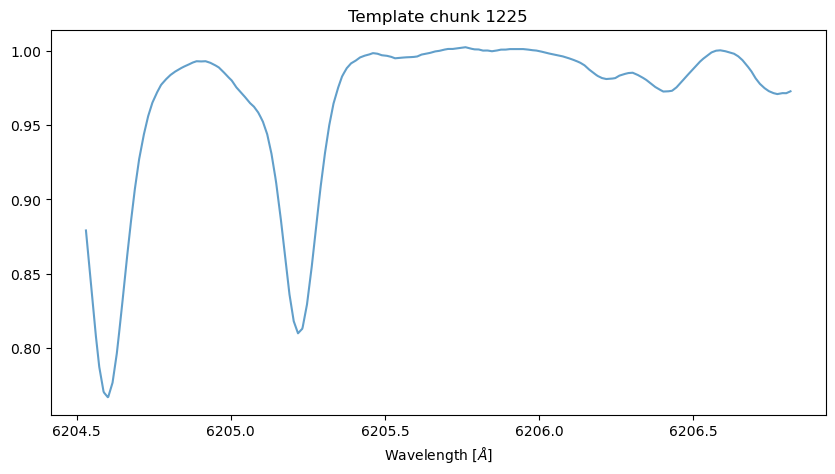

2.2859593465545913 wavelength chunk A


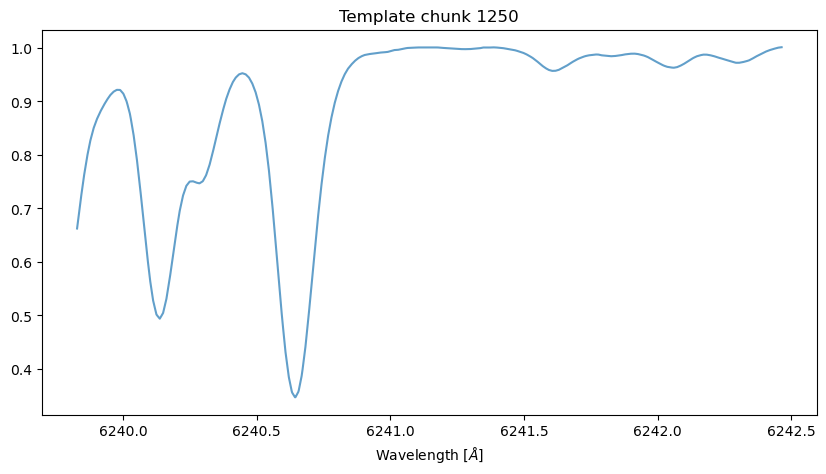

2.6348704388574333 wavelength chunk A


In [25]:
chunk_sizes_A = []
for i, chunk in enumerate(arcturus_temp.chunks):
# only plot every 25th chunk
    if i % 25 == 0:

        plt.figure(figsize=(10,5))
        plt.plot(chunk.wave, chunk.flux, alpha=0.7)
        plt.title(f'Template chunk {i}')
        plt.xlabel(r'Wavelength [$\AA$]')
        plt.show()
        print(np.max(chunk.wave)-np.min((chunk.wave)),'wavelength chunk A')
        #append chunk size
        chunk_sizes_A.append(np.max(chunk.wave)-np.min((chunk.wave)))

1491
51 !


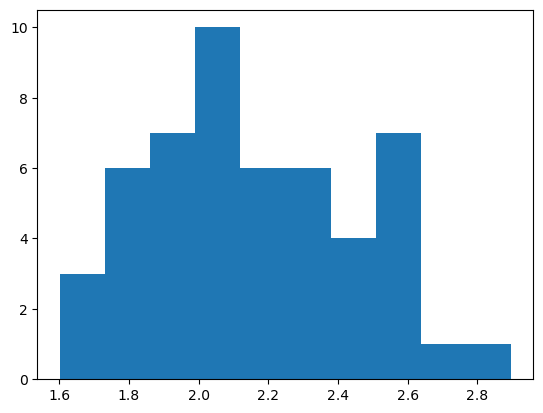

In [30]:
#histogram of chunksizes
plt.hist(chunk_sizes_A)
print(len(chunk))
print(len(chunk_sizes_A),'!')